# **Project Assignment \#6 - Adversarial AI in Games(Briscas)**

<br>

**University of Puerto Rico, Mayagüez Campus**  
**Electrical and Computer Engineering Department**

---

<br>

### Prepared by:
Jael A. Gonzalez De Arce  

Jayson D. Perez Ramirez

Néstor O. Santos Torres  


# How to Run the Notebook

To reproduce the experiments and results presented in this project, execute all notebook cells sequentially from top to bottom.

The notebook is organized into the following sections:

1. Supporting utility functions  
2. Briscas game definition and environment implementation  
3. Hidden state sampling for partial observability  
4. Baseline agent implementations  
5. Monte Carlo simulation agent  
6. Game execution loop  
7. Agent performance evaluation  
8. Experimental execution  
9. Visualization and comparison of results  
10. Optional Human vs AI gameplay  
11. Technical report

Recommended Python version:
- Python 3.10 or newer

The following external libraries may need to be installed before execution:

- numpy
- pandas
- matplotlib

The project also uses standard Python libraries including:

- random
- copy
- math
- time
- collections

Some Monte Carlo experiments with high rollout counts may require several minutes to complete depending on hardware performance.

Where applicable, random seeds were fixed to improve reproducibility of results.

# About the Report

The report for the assignment is included in the final section of the notebook.

This notebook was developed using Google Colab. Figures and tables are embedded directly into the notebook to preserve formatting and portability across supported environments. If visualization issues occur, please contact the authors for separate copies of the generated figures and tables.

# Supporting Utility Functions

This section contains generic utility and game framework functions from the AIMA Python repository.

In [1]:
#utils.py from berkley repository
"""Provides some utilities widely used by other modules"""

import bisect
import collections
import collections.abc
import functools
import heapq
import operator
import os.path
import random
from itertools import chain, combinations
from statistics import mean

import numpy as np


# ______________________________________________________________________________
# Functions on Sequences and Iterables


def sequence(iterable):
    """Converts iterable to sequence, if it is not already one."""
    return iterable if isinstance(iterable, collections.abc.Sequence) else tuple([iterable])


def remove_all(item, seq):
    """Return a copy of seq (or string) with all occurrences of item removed."""
    if isinstance(seq, str):
        return seq.replace(item, '')
    elif isinstance(seq, set):
        rest = seq.copy()
        rest.remove(item)
        return rest
    else:
        return [x for x in seq if x != item]


def unique(seq):
    """Remove duplicate elements from seq. Assumes hashable elements."""
    return list(set(seq))


def count(seq):
    """Count the number of items in sequence that are interpreted as true."""
    return sum(map(bool, seq))


def multimap(items):
    """Given (key, val) pairs, return {key: [val, ....], ...}."""
    result = collections.defaultdict(list)
    for (key, val) in items:
        result[key].append(val)
    return dict(result)


def multimap_items(mmap):
    """Yield all (key, val) pairs stored in the multimap."""
    for (key, vals) in mmap.items():
        for val in vals:
            yield key, val


def product(numbers):
    """Return the product of the numbers, e.g. product([2, 3, 10]) == 60"""
    result = 1
    for x in numbers:
        result *= x
    return result


def first(iterable, default=None):
    """Return the first element of an iterable; or default."""
    return next(iter(iterable), default)


def is_in(elt, seq):
    """Similar to (elt in seq), but compares with 'is', not '=='."""
    return any(x is elt for x in seq)


def mode(data):
    """Return the most common data item. If there are ties, return any one of them."""
    [(item, count)] = collections.Counter(data).most_common(1)
    return item


def power_set(iterable):
    """power_set([1,2,3]) --> (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"""
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))[1:]


def extend(s, var, val):
    """Copy dict s and extend it by setting var to val; return copy."""
    return {**s, var: val}


def flatten(seqs):
    return sum(seqs, [])


# ______________________________________________________________________________
# argmin and argmax

identity = lambda x: x


def argmin_random_tie(seq, key=identity):
    """Return a minimum element of seq; break ties at random."""
    return min(shuffled(seq), key=key)


def argmax_random_tie(seq, key=identity):
    """Return an element with highest fn(seq[i]) score; break ties at random."""
    return max(shuffled(seq), key=key)


def shuffled(iterable):
    """Randomly shuffle a copy of iterable."""
    items = list(iterable)
    random.shuffle(items)
    return items


# ______________________________________________________________________________
# Statistical and mathematical functions


def histogram(values, mode=0, bin_function=None):
    """Return a list of (value, count) pairs, summarizing the input values.
    Sorted by increasing value, or if mode=1, by decreasing count.
    If bin_function is given, map it over values first."""
    if bin_function:
        values = map(bin_function, values)

    bins = {}
    for val in values:
        bins[val] = bins.get(val, 0) + 1

    if mode:
        return sorted(list(bins.items()), key=lambda x: (x[1], x[0]), reverse=True)
    else:
        return sorted(bins.items())


def dot_product(x, y):
    """Return the sum of the element-wise product of vectors x and y."""
    return sum(_x * _y for _x, _y in zip(x, y))


def element_wise_product(x, y):
    """Return vector as an element-wise product of vectors x and y."""
    assert len(x) == len(y)
    return np.multiply(x, y)


def matrix_multiplication(x, *y):
    """Return a matrix as a matrix-multiplication of x and arbitrary number of matrices *y."""

    result = x
    for _y in y:
        result = np.matmul(result, _y)

    return result


def vector_add(a, b):
    """Component-wise addition of two vectors."""
    return tuple(map(operator.add, a, b))


def scalar_vector_product(x, y):
    """Return vector as a product of a scalar and a vector"""
    return np.multiply(x, y)


def probability(p):
    """Return true with probability p."""
    return p > random.uniform(0.0, 1.0)


def weighted_sample_with_replacement(n, seq, weights):
    """Pick n samples from seq at random, with replacement, with the
    probability of each element in proportion to its corresponding
    weight."""
    sample = weighted_sampler(seq, weights)
    return [sample() for _ in range(n)]


def weighted_sampler(seq, weights):
    """Return a random-sample function that picks from seq weighted by weights."""
    totals = []
    for w in weights:
        totals.append(w + totals[-1] if totals else w)
    return lambda: seq[bisect.bisect(totals, random.uniform(0, totals[-1]))]


def weighted_choice(choices):
    """A weighted version of random.choice"""
    # NOTE: should be replaced by random.choices if we port to Python 3.6

    total = sum(w for _, w in choices)
    r = random.uniform(0, total)
    upto = 0
    for c, w in choices:
        if upto + w >= r:
            return c, w
        upto += w


def rounder(numbers, d=4):
    """Round a single number, or sequence of numbers, to d decimal places."""
    if isinstance(numbers, (int, float)):
        return round(numbers, d)
    else:
        constructor = type(numbers)  # Can be list, set, tuple, etc.
        return constructor(rounder(n, d) for n in numbers)


def num_or_str(x):  # TODO: rename as `atom`
    """The argument is a string; convert to a number if possible, or strip it."""
    try:
        return int(x)
    except ValueError:
        try:
            return float(x)
        except ValueError:
            return str(x).strip()


def euclidean_distance(x, y):
    return np.sqrt(sum((_x - _y) ** 2 for _x, _y in zip(x, y)))


def manhattan_distance(x, y):
    return sum(abs(_x - _y) for _x, _y in zip(x, y))


def hamming_distance(x, y):
    return sum(_x != _y for _x, _y in zip(x, y))


def cross_entropy_loss(x, y):
    return (-1.0 / len(x)) * sum(_x * np.log(_y) + (1 - _x) * np.log(1 - _y) for _x, _y in zip(x, y))


def mean_squared_error_loss(x, y):
    return (1.0 / len(x)) * sum((_x - _y) ** 2 for _x, _y in zip(x, y))


def rms_error(x, y):
    return np.sqrt(ms_error(x, y))


def ms_error(x, y):
    return mean((_x - _y) ** 2 for _x, _y in zip(x, y))


def mean_error(x, y):
    return mean(abs(_x - _y) for _x, _y in zip(x, y))


def mean_boolean_error(x, y):
    return mean(_x != _y for _x, _y in zip(x, y))


def normalize(dist):
    """Multiply each number by a constant such that the sum is 1.0"""
    if isinstance(dist, dict):
        total = sum(dist.values())
        for key in dist:
            dist[key] = dist[key] / total
            assert 0 <= dist[key] <= 1  # probabilities must be between 0 and 1
        return dist
    total = sum(dist)
    return [(n / total) for n in dist]


def random_weights(min_value, max_value, num_weights):
    return [random.uniform(min_value, max_value) for _ in range(num_weights)]


def sigmoid(x):
    """Return activation value of x with sigmoid function."""
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(value):
    return value * (1 - value)


def elu(x, alpha=0.01):
    return x if x > 0 else alpha * (np.exp(x) - 1)


def elu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha * np.exp(value)


def tanh(x):
    return np.tanh(x)


def tanh_derivative(value):
    return 1 - (value ** 2)


def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x


def leaky_relu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha


def relu(x):
    return max(0, x)


def relu_derivative(value):
    return 1 if value > 0 else 0


def step(x):
    """Return activation value of x with sign function"""
    return 1 if x >= 0 else 0


def gaussian(mean, st_dev, x):
    """Given the mean and standard deviation of a distribution, it returns the probability of x."""
    return 1 / (np.sqrt(2 * np.pi) * st_dev) * np.e ** (-0.5 * (float(x - mean) / st_dev) ** 2)


def linear_kernel(x, y=None):
    if y is None:
        y = x
    return np.dot(x, y.T)


def polynomial_kernel(x, y=None, degree=2.0):
    if y is None:
        y = x
    return (1.0 + np.dot(x, y.T)) ** degree


def rbf_kernel(x, y=None, gamma=None):
    """Radial-basis function kernel (aka squared-exponential kernel)."""
    if y is None:
        y = x
    if gamma is None:
        gamma = 1.0 / x.shape[1]  # 1.0 / n_features
    return np.exp(-gamma * (-2.0 * np.dot(x, y.T) +
                            np.sum(x * x, axis=1).reshape((-1, 1)) + np.sum(y * y, axis=1).reshape((1, -1))))


# ______________________________________________________________________________
# Grid Functions


orientations = EAST, NORTH, WEST, SOUTH = [(1, 0), (0, 1), (-1, 0), (0, -1)]
turns = LEFT, RIGHT = (+1, -1)


def turn_heading(heading, inc, headings=orientations):
    return headings[(headings.index(heading) + inc) % len(headings)]


def turn_right(heading):
    return turn_heading(heading, RIGHT)


def turn_left(heading):
    return turn_heading(heading, LEFT)


def distance(a, b):
    """The distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return np.hypot((xA - xB), (yA - yB))


def distance_squared(a, b):
    """The square of the distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return (xA - xB) ** 2 + (yA - yB) ** 2


# ______________________________________________________________________________
# Misc Functions

class injection:
    """Dependency injection of temporary values for global functions/classes/etc.
    E.g., `with injection(DataBase=MockDataBase): ...`"""

    def __init__(self, **kwds):
        self.new = kwds

    def __enter__(self):
        self.old = {v: globals()[v] for v in self.new}
        globals().update(self.new)

    def __exit__(self, type, value, traceback):
        globals().update(self.old)


def memoize(fn, slot=None, maxsize=32):
    """Memoize fn: make it remember the computed value for any argument list.
    If slot is specified, store result in that slot of first argument.
    If slot is false, use lru_cache for caching the values."""
    if slot:
        def memoized_fn(obj, *args):
            if hasattr(obj, slot):
                return getattr(obj, slot)
            else:
                val = fn(obj, *args)
                setattr(obj, slot, val)
                return val
    else:
        @functools.lru_cache(maxsize=maxsize)
        def memoized_fn(*args):
            return fn(*args)

    return memoized_fn


def name(obj):
    """Try to find some reasonable name for the object."""
    return (getattr(obj, 'name', 0) or getattr(obj, '__name__', 0) or
            getattr(getattr(obj, '__class__', 0), '__name__', 0) or
            str(obj))


def isnumber(x):
    """Is x a number?"""
    return hasattr(x, '__int__')


def issequence(x):
    """Is x a sequence?"""
    return isinstance(x, collections.abc.Sequence)


def print_table(table, header=None, sep='   ', numfmt='{}'):
    """Print a list of lists as a table, so that columns line up nicely.
    header, if specified, will be printed as the first row.
    numfmt is the format for all numbers; you might want e.g. '{:.2f}'.
    (If you want different formats in different columns,
    don't use print_table.) sep is the separator between columns."""
    justs = ['rjust' if isnumber(x) else 'ljust' for x in table[0]]

    if header:
        table.insert(0, header)

    table = [[numfmt.format(x) if isnumber(x) else x for x in row]
             for row in table]

    sizes = list(map(lambda seq: max(map(len, seq)), list(zip(*[map(str, row) for row in table]))))

    for row in table:
        print(sep.join(getattr(str(x), j)(size) for (j, size, x) in zip(justs, sizes, row)))


def open_data(name, mode='r'):
    aima_root = os.path.dirname(__file__)
    aima_file = os.path.join(aima_root, *['aima-data', name])

    return open(aima_file, mode=mode)


def failure_test(algorithm, tests):
    """Grades the given algorithm based on how many tests it passes.
    Most algorithms have arbitrary output on correct execution, which is difficult
    to check for correctness. On the other hand, a lot of algorithms output something
    particular on fail (for example, False, or None).
    tests is a list with each element in the form: (values, failure_output)."""
    return mean(int(algorithm(x) != y) for x, y in tests)


# ______________________________________________________________________________
# Expressions

# See https://docs.python.org/3/reference/expressions.html#operator-precedence
# See https://docs.python.org/3/reference/datamodel.html#special-method-names

class Expr:
    """A mathematical expression with an operator and 0 or more arguments.
    op is a str like '+' or 'sin'; args are Expressions.
    Expr('x') or Symbol('x') creates a symbol (a nullary Expr).
    Expr('-', x) creates a unary; Expr('+', x, 1) creates a binary."""

    def __init__(self, op, *args):
        self.op = str(op)
        self.args = args

    # Operator overloads
    def __neg__(self):
        return Expr('-', self)

    def __pos__(self):
        return Expr('+', self)

    def __invert__(self):
        return Expr('~', self)

    def __add__(self, rhs):
        return Expr('+', self, rhs)

    def __sub__(self, rhs):
        return Expr('-', self, rhs)

    def __mul__(self, rhs):
        return Expr('*', self, rhs)

    def __pow__(self, rhs):
        return Expr('**', self, rhs)

    def __mod__(self, rhs):
        return Expr('%', self, rhs)

    def __and__(self, rhs):
        return Expr('&', self, rhs)

    def __xor__(self, rhs):
        return Expr('^', self, rhs)

    def __rshift__(self, rhs):
        return Expr('>>', self, rhs)

    def __lshift__(self, rhs):
        return Expr('<<', self, rhs)

    def __truediv__(self, rhs):
        return Expr('/', self, rhs)

    def __floordiv__(self, rhs):
        return Expr('//', self, rhs)

    def __matmul__(self, rhs):
        return Expr('@', self, rhs)

    def __or__(self, rhs):
        """Allow both P | Q, and P |'==>'| Q."""
        if isinstance(rhs, Expression):
            return Expr('|', self, rhs)
        else:
            return PartialExpr(rhs, self)

    # Reverse operator overloads
    def __radd__(self, lhs):
        return Expr('+', lhs, self)

    def __rsub__(self, lhs):
        return Expr('-', lhs, self)

    def __rmul__(self, lhs):
        return Expr('*', lhs, self)

    def __rdiv__(self, lhs):
        return Expr('/', lhs, self)

    def __rpow__(self, lhs):
        return Expr('**', lhs, self)

    def __rmod__(self, lhs):
        return Expr('%', lhs, self)

    def __rand__(self, lhs):
        return Expr('&', lhs, self)

    def __rxor__(self, lhs):
        return Expr('^', lhs, self)

    def __ror__(self, lhs):
        return Expr('|', lhs, self)

    def __rrshift__(self, lhs):
        return Expr('>>', lhs, self)

    def __rlshift__(self, lhs):
        return Expr('<<', lhs, self)

    def __rtruediv__(self, lhs):
        return Expr('/', lhs, self)

    def __rfloordiv__(self, lhs):
        return Expr('//', lhs, self)

    def __rmatmul__(self, lhs):
        return Expr('@', lhs, self)

    def __call__(self, *args):
        """Call: if 'f' is a Symbol, then f(0) == Expr('f', 0)."""
        if self.args:
            raise ValueError('Can only do a call for a Symbol, not an Expr')
        else:
            return Expr(self.op, *args)

    # Equality and repr
    def __eq__(self, other):
        """x == y' evaluates to True or False; does not build an Expr."""
        return isinstance(other, Expr) and self.op == other.op and self.args == other.args

    def __lt__(self, other):
        return isinstance(other, Expr) and str(self) < str(other)

    def __hash__(self):
        return hash(self.op) ^ hash(self.args)

    def __repr__(self):
        op = self.op
        args = [str(arg) for arg in self.args]
        if op.isidentifier():  # f(x) or f(x, y)
            return '{}({})'.format(op, ', '.join(args)) if args else op
        elif len(args) == 1:  # -x or -(x + 1)
            return op + args[0]
        else:  # (x - y)
            opp = (' ' + op + ' ')
            return '(' + opp.join(args) + ')'


# An 'Expression' is either an Expr or a Number.
# Symbol is not an explicit type; it is any Expr with 0 args.


Number = (int, float, complex)
Expression = (Expr, Number)


def Symbol(name):
    """A Symbol is just an Expr with no args."""
    return Expr(name)


def symbols(names):
    """Return a tuple of Symbols; names is a comma/whitespace delimited str."""
    return tuple(Symbol(name) for name in names.replace(',', ' ').split())


def subexpressions(x):
    """Yield the subexpressions of an Expression (including x itself)."""
    yield x
    if isinstance(x, Expr):
        for arg in x.args:
            yield from subexpressions(arg)


def arity(expression):
    """The number of sub-expressions in this expression."""
    if isinstance(expression, Expr):
        return len(expression.args)
    else:  # expression is a number
        return 0


# For operators that are not defined in Python, we allow new InfixOps:


class PartialExpr:
    """Given 'P |'==>'| Q, first form PartialExpr('==>', P), then combine with Q."""

    def __init__(self, op, lhs):
        self.op, self.lhs = op, lhs

    def __or__(self, rhs):
        return Expr(self.op, self.lhs, rhs)

    def __repr__(self):
        return "PartialExpr('{}', {})".format(self.op, self.lhs)


def expr(x):
    """Shortcut to create an Expression. x is a str in which:
    - identifiers are automatically defined as Symbols.
    - ==> is treated as an infix |'==>'|, as are <== and <=>.
    If x is already an Expression, it is returned unchanged. Example:
    >>> expr('P & Q ==> Q')
    ((P & Q) ==> Q)
    """
    return eval(expr_handle_infix_ops(x), defaultkeydict(Symbol)) if isinstance(x, str) else x


infix_ops = '==> <== <=>'.split()


def expr_handle_infix_ops(x):
    """Given a str, return a new str with ==> replaced by |'==>'|, etc.
    >>> expr_handle_infix_ops('P ==> Q')
    "P |'==>'| Q"
    """
    for op in infix_ops:
        x = x.replace(op, '|' + repr(op) + '|')
    return x


class defaultkeydict(collections.defaultdict):
    """Like defaultdict, but the default_factory is a function of the key.
    >>> d = defaultkeydict(len); d['four']
    4
    """

    def __missing__(self, key):
        self[key] = result = self.default_factory(key)
        return result


class hashabledict(dict):
    """Allows hashing by representing a dictionary as tuple of key:value pairs.
    May cause problems as the hash value may change during runtime."""

    def __hash__(self):
        return 1


# ______________________________________________________________________________
# Queues: Stack, FIFOQueue, PriorityQueue
# Stack and FIFOQueue are implemented as list and collection.deque
# PriorityQueue is implemented here


class PriorityQueue:
    """A Queue in which the minimum (or maximum) element (as determined by f and
    order) is returned first.
    If order is 'min', the item with minimum f(x) is
    returned first; if order is 'max', then it is the item with maximum f(x).
    Also supports dict-like lookup."""

    def __init__(self, order='min', f=lambda x: x):
        self.heap = []
        if order == 'min':
            self.f = f
        elif order == 'max':  # now item with max f(x)
            self.f = lambda x: -f(x)  # will be popped first
        else:
            raise ValueError("Order must be either 'min' or 'max'.")

    def append(self, item):
        """Insert item at its correct position."""
        heapq.heappush(self.heap, (self.f(item), item))

    def extend(self, items):
        """Insert each item in items at its correct position."""
        for item in items:
            self.append(item)

    def pop(self):
        """Pop and return the item (with min or max f(x) value)
        depending on the order."""
        if self.heap:
            return heapq.heappop(self.heap)[1]
        else:
            raise Exception('Trying to pop from empty PriorityQueue.')

    def __len__(self):
        """Return current capacity of PriorityQueue."""
        return len(self.heap)

    def __contains__(self, key):
        """Return True if the key is in PriorityQueue."""
        return any([item == key for _, item in self.heap])

    def __getitem__(self, key):
        """Returns the first value associated with key in PriorityQueue.
        Raises KeyError if key is not present."""
        for value, item in self.heap:
            if item == key:
                return value
        raise KeyError(str(key) + " is not in the priority queue")

    def __delitem__(self, key):
        """Delete the first occurrence of key."""
        try:
            del self.heap[[item == key for _, item in self.heap].index(True)]
        except ValueError:
            raise KeyError(str(key) + " is not in the priority queue")
        heapq.heapify(self.heap)


# ______________________________________________________________________________
# Useful Shorthands


class Bool(int):
    """Just like `bool`, except values display as 'T' and 'F' instead of 'True' and 'False'."""
    __str__ = __repr__ = lambda self: 'T' if self else 'F'


T = Bool(True)
F = Bool(False)


In [2]:
"""Games or Adversarial Search (Chapter 5)"""

import copy
import itertools
import random
from collections import namedtuple

import numpy as np


GameState = namedtuple('GameState', 'to_move, utility, board, moves')
StochasticGameState = namedtuple('StochasticGameState', 'to_move, utility, board, moves, chance')


# ______________________________________________________________________________
# MinMax Search


def minmax_decision(state, game):
    """Given a state in a game, calculate the best move by searching
    forward all the way to the terminal states. [Figure 5.3]"""

    player = game.to_move(state)

    def max_value(state):
        if game.terminal_test(state):
            return game.utility(state, player)
        v = -np.inf
        for a in game.actions(state):
            v = max(v, min_value(game.result(state, a)))
        return v

    def min_value(state):
        if game.terminal_test(state):
            return game.utility(state, player)
        v = np.inf
        for a in game.actions(state):
            v = min(v, max_value(game.result(state, a)))
        return v

    # Body of minmax_decision:
    return max(game.actions(state), key=lambda a: min_value(game.result(state, a)))


# ______________________________________________________________________________


def expect_minmax(state, game):
    """
    [Figure 5.11]
    Return the best move for a player after dice are thrown. The game tree
	includes chance nodes along with min and max nodes.
	"""
    player = game.to_move(state)

    def max_value(state):
        v = -np.inf
        for a in game.actions(state):
            v = max(v, chance_node(state, a))
        return v

    def min_value(state):
        v = np.inf
        for a in game.actions(state):
            v = min(v, chance_node(state, a))
        return v

    def chance_node(state, action):
        res_state = game.result(state, action)
        if game.terminal_test(res_state):
            return game.utility(res_state, player)
        sum_chances = 0
        num_chances = len(game.chances(res_state))
        for chance in game.chances(res_state):
            res_state = game.outcome(res_state, chance)
            util = 0
            if res_state.to_move == player:
                util = max_value(res_state)
            else:
                util = min_value(res_state)
            sum_chances += util * game.probability(chance)
        return sum_chances / num_chances

    # Body of expect_minmax:
    return max(game.actions(state), key=lambda a: chance_node(state, a), default=None)


def alpha_beta_search(state, game):
    """Search game to determine best action; use alpha-beta pruning.
    As in [Figure 5.7], this version searches all the way to the leaves."""

    player = game.to_move(state)

    # Functions used by alpha_beta
    def max_value(state, alpha, beta):
        if game.terminal_test(state):
            return game.utility(state, player)
        v = -np.inf
        for a in game.actions(state):
            v = max(v, min_value(game.result(state, a), alpha, beta))
            if v >= beta:
                return v
            alpha = max(alpha, v)
        return v

    def min_value(state, alpha, beta):
        if game.terminal_test(state):
            return game.utility(state, player)
        v = np.inf
        for a in game.actions(state):
            v = min(v, max_value(game.result(state, a), alpha, beta))
            if v <= alpha:
                return v
            beta = min(beta, v)
        return v

    # Body of alpha_beta_search:
    best_score = -np.inf
    beta = np.inf
    best_action = None
    for a in game.actions(state):
        v = min_value(game.result(state, a), best_score, beta)
        if v > best_score:
            best_score = v
            best_action = a
    return best_action


def alpha_beta_cutoff_search(state, game, d=4, cutoff_test=None, eval_fn=None):
    """Search game to determine best action; use alpha-beta pruning.
    This version cuts off search and uses an evaluation function."""

    player = game.to_move(state)

    # Functions used by alpha_beta
    def max_value(state, alpha, beta, depth):
        if cutoff_test(state, depth):
            return eval_fn(state)
        v = -np.inf
        for a in game.actions(state):
            v = max(v, min_value(game.result(state, a), alpha, beta, depth + 1))
            if v >= beta:
                return v
            alpha = max(alpha, v)
        return v

    def min_value(state, alpha, beta, depth):
        if cutoff_test(state, depth):
            return eval_fn(state)
        v = np.inf
        for a in game.actions(state):
            v = min(v, max_value(game.result(state, a), alpha, beta, depth + 1))
            if v <= alpha:
                return v
            beta = min(beta, v)
        return v

    # Body of alpha_beta_cutoff_search starts here:
    # The default test cuts off at depth d or at a terminal state
    cutoff_test = (cutoff_test or (lambda state, depth: depth > d or game.terminal_test(state)))
    eval_fn = eval_fn or (lambda state: game.utility(state, player))
    best_score = -np.inf
    beta = np.inf
    best_action = None
    for a in game.actions(state):
        v = min_value(game.result(state, a), best_score, beta, 1)
        if v > best_score:
            best_score = v
            best_action = a
    return best_action


# ______________________________________________________________________________
# Players for Games


def query_player(game, state):
    """Make a move by querying standard input."""
    print("current state:")
    game.display(state)
    print("available moves: {}".format(game.actions(state)))
    print("")
    move = None
    if game.actions(state):
        move_string = input('Your move? ')
        try:
            move = eval(move_string)
        except NameError:
            move = move_string
    else:
        print('no legal moves: passing turn to next player')
    return move


def random_player(game, state):
    """A player that chooses a legal move at random."""
    return random.choice(game.actions(state)) if game.actions(state) else None


def alpha_beta_player(game, state):
    return alpha_beta_search(state, game)


def minmax_player(game,state):
    return minmax_decision(state,game)


def expect_minmax_player(game, state):
    return expect_minmax(state, game)


# ______________________________________________________________________________
# Some Sample Games


class Game:
    """A game is similar to a problem, but it has a utility for each
    state and a terminal test instead of a path cost and a goal
    test. To create a game, subclass this class and implement actions,
    result, utility, and terminal_test. You may override display and
    successors or you can inherit their default methods. You will also
    need to set the .initial attribute to the initial state; this can
    be done in the constructor."""

    def actions(self, state):
        """Return a list of the allowable moves at this point."""
        raise NotImplementedError

    def result(self, state, move):
        """Return the state that results from making a move from a state."""
        raise NotImplementedError

    def utility(self, state, player):
        """Return the value of this final state to player."""
        raise NotImplementedError

    def terminal_test(self, state):
        """Return True if this is a final state for the game."""
        return not self.actions(state)

    def to_move(self, state):
        """Return the player whose move it is in this state."""
        return state.to_move

    def display(self, state):
        """Print or otherwise display the state."""
        print(state)

    def __repr__(self):
        return '<{}>'.format(self.__class__.__name__)

    def play_game(self, *players):
        """Play an n-person, move-alternating game."""
        state = self.initial
        while True:
            for player in players:
                move = player(self, state)
                state = self.result(state, move)
                if self.terminal_test(state):
                    self.display(state)
                    return self.utility(state, self.to_move(self.initial))


class StochasticGame(Game):
    """A stochastic game includes uncertain events which influence
    the moves of players at each state. To create a stochastic game, subclass
    this class and implement chances and outcome along with the other
    unimplemented game class methods."""

    def chances(self, state):
        """Return a list of all possible uncertain events at a state."""
        raise NotImplementedError

    def outcome(self, state, chance):
        """Return the state which is the outcome of a chance trial."""
        raise NotImplementedError

    def probability(self, chance):
        """Return the probability of occurrence of a chance."""
        raise NotImplementedError

    def play_game(self, *players):
        """Play an n-person, move-alternating stochastic game."""
        state = self.initial
        while True:
            for player in players:
                chance = random.choice(self.chances(state))
                state = self.outcome(state, chance)
                move = player(self, state)
                state = self.result(state, move)
                if self.terminal_test(state):
                    self.display(state)
                    return self.utility(state, self.to_move(self.initial))


class Fig52Game(Game):
    """The game represented in [Figure 5.2]. Serves as a simple test case."""

    succs = dict(A=dict(a1='B', a2='C', a3='D'),
                 B=dict(b1='B1', b2='B2', b3='B3'),
                 C=dict(c1='C1', c2='C2', c3='C3'),
                 D=dict(d1='D1', d2='D2', d3='D3'))
    utils = dict(B1=3, B2=12, B3=8, C1=2, C2=4, C3=6, D1=14, D2=5, D3=2)
    initial = 'A'

    def actions(self, state):
        return list(self.succs.get(state, {}).keys())

    def result(self, state, move):
        return self.succs[state][move]

    def utility(self, state, player):
        if player == 'MAX':
            return self.utils[state]
        else:
            return -self.utils[state]

    def terminal_test(self, state):
        return state not in ('A', 'B', 'C', 'D')

    def to_move(self, state):
        return 'MIN' if state in 'BCD' else 'MAX'


class Fig52Extended(Game):
    """Similar to Fig52Game but bigger. Useful for visualisation"""

    succs = {i: dict(l=i * 3 + 1, m=i * 3 + 2, r=i * 3 + 3) for i in range(13)}
    utils = dict()

    def actions(self, state):
        return sorted(list(self.succs.get(state, {}).keys()))

    def result(self, state, move):
        return self.succs[state][move]

    def utility(self, state, player):
        if player == 'MAX':
            return self.utils[state]
        else:
            return -self.utils[state]

    def terminal_test(self, state):
        return state not in range(13)

    def to_move(self, state):
        return 'MIN' if state in {1, 2, 3} else 'MAX'


class TicTacToe(Game):
    """Play TicTacToe on an h x v board, with Max (first player) playing 'X'.
    A state has the player to move, a cached utility, a list of moves in
    the form of a list of (x, y) positions, and a board, in the form of
    a dict of {(x, y): Player} entries, where Player is 'X' or 'O'."""

    def __init__(self, h=3, v=3, k=3):
        self.h = h
        self.v = v
        self.k = k
        moves = [(x, y) for x in range(1, h + 1)
                 for y in range(1, v + 1)]
        self.initial = GameState(to_move='X', utility=0, board={}, moves=moves)

    def actions(self, state):
        """Legal moves are any square not yet taken."""
        return state.moves

    def result(self, state, move):
        if move not in state.moves:
            return state  # Illegal move has no effect
        board = state.board.copy()
        board[move] = state.to_move
        moves = list(state.moves)
        moves.remove(move)
        return GameState(to_move=('O' if state.to_move == 'X' else 'X'),
                         utility=self.compute_utility(board, move, state.to_move),
                         board=board, moves=moves)

    def utility(self, state, player):
        """Return the value to player; 1 for win, -1 for loss, 0 otherwise."""
        return state.utility if player == 'X' else -state.utility

    def terminal_test(self, state):
        """A state is terminal if it is won or there are no empty squares."""
        return state.utility != 0 or len(state.moves) == 0

    def display(self, state):
        board = state.board
        for x in range(1, self.h + 1):
            for y in range(1, self.v + 1):
                print(board.get((x, y), '.'), end=' ')
            print()

    def compute_utility(self, board, move, player):
        """If 'X' wins with this move, return 1; if 'O' wins return -1; else return 0."""
        if (self.k_in_row(board, move, player, (0, 1)) or
                self.k_in_row(board, move, player, (1, 0)) or
                self.k_in_row(board, move, player, (1, -1)) or
                self.k_in_row(board, move, player, (1, 1))):
            return +1 if player == 'X' else -1
        else:
            return 0

    def k_in_row(self, board, move, player, delta_x_y):
        """Return true if there is a line through move on board for player."""
        (delta_x, delta_y) = delta_x_y
        x, y = move
        n = 0  # n is number of moves in row
        while board.get((x, y)) == player:
            n += 1
            x, y = x + delta_x, y + delta_y
        x, y = move
        while board.get((x, y)) == player:
            n += 1
            x, y = x - delta_x, y - delta_y
        n -= 1  # Because we counted move itself twice
        return n >= self.k


class ConnectFour(TicTacToe):
    """A TicTacToe-like game in which you can only make a move on the bottom
    row, or in a square directly above an occupied square.  Traditionally
    played on a 7x6 board and requiring 4 in a row."""

    def __init__(self, h=7, v=6, k=4):
        TicTacToe.__init__(self, h, v, k)

    def actions(self, state):
        return [(x, y) for (x, y) in state.moves
                if x == self.h or (x + 1 , y ) in state.board]

class Gomoku(TicTacToe):
    """Also known as Five in a row."""

    def __init__(self, h=15, v=16, k=5):
        TicTacToe.__init__(self, h, v, k)


class Backgammon(StochasticGame):
    """A two player game where the goal of each player is to move all the
	checkers off the board. The moves for each state are determined by
	rolling a pair of dice."""

    def __init__(self):
        """Initial state of the game"""
        point = {'W': 0, 'B': 0}
        board = [point.copy() for index in range(24)]
        board[0]['B'] = board[23]['W'] = 2
        board[5]['W'] = board[18]['B'] = 5
        board[7]['W'] = board[16]['B'] = 3
        board[11]['B'] = board[12]['W'] = 5
        self.allow_bear_off = {'W': False, 'B': False}
        self.direction = {'W': -1, 'B': 1}
        self.initial = StochasticGameState(to_move='W',
                                           utility=0,
                                           board=board,
                                           moves=self.get_all_moves(board, 'W'), chance=None)

    def actions(self, state):
        """Return a list of legal moves for a state."""
        player = state.to_move
        moves = state.moves
        if len(moves) == 1 and len(moves[0]) == 1:
            return moves
        legal_moves = []
        for move in moves:
            board = copy.deepcopy(state.board)
            if self.is_legal_move(board, move, state.chance, player):
                legal_moves.append(move)
        return legal_moves

    def result(self, state, move):
        board = copy.deepcopy(state.board)
        player = state.to_move
        self.move_checker(board, move[0], state.chance[0], player)
        if len(move) == 2:
            self.move_checker(board, move[1], state.chance[1], player)
        to_move = ('W' if player == 'B' else 'B')
        return StochasticGameState(to_move=to_move,
                                   utility=self.compute_utility(board, move, player),
                                   board=board,
                                   moves=self.get_all_moves(board, to_move), chance=None)

    def utility(self, state, player):
        """Return the value to player; 1 for win, -1 for loss, 0 otherwise."""
        return state.utility if player == 'W' else -state.utility

    def terminal_test(self, state):
        """A state is terminal if one player wins."""
        return state.utility != 0

    def get_all_moves(self, board, player):
        """All possible moves for a player i.e. all possible ways of
        choosing two checkers of a player from the board for a move
        at a given state."""
        all_points = board
        taken_points = [index for index, point in enumerate(all_points)
                        if point[player] > 0]
        if self.checkers_at_home(board, player) == 1:
            return [(taken_points[0],)]
        moves = list(itertools.permutations(taken_points, 2))
        moves = moves + [(index, index) for index, point in enumerate(all_points)
                         if point[player] >= 2]
        return moves

    def display(self, state):
        """Display state of the game."""
        board = state.board
        player = state.to_move
        print("current state : ")
        for index, point in enumerate(board):
            print("point : ", index, "	W : ", point['W'], "    B : ", point['B'])
        print("to play : ", player)

    def compute_utility(self, board, move, player):
        """If 'W' wins with this move, return 1; if 'B' wins return -1; else return 0."""
        util = {'W': 1, 'B': -1}
        for idx in range(0, 24):
            if board[idx][player] > 0:
                return 0
        return util[player]

    def checkers_at_home(self, board, player):
        """Return the no. of checkers at home for a player."""
        sum_range = range(0, 7) if player == 'W' else range(17, 24)
        count = 0
        for idx in sum_range:
            count = count + board[idx][player]
        return count

    def is_legal_move(self, board, start, steps, player):
        """Move is a tuple which contains starting points of checkers to be
		moved during a player's turn. An on-board move is legal if both the destinations
		are open. A bear-off move is the one where a checker is moved off-board.
        It is legal only after a player has moved all his checkers to his home."""
        dest1, dest2 = vector_add(start, steps)
        dest_range = range(0, 24)
        move1_legal = move2_legal = False
        if dest1 in dest_range:
            if self.is_point_open(player, board[dest1]):
                self.move_checker(board, start[0], steps[0], player)
                move1_legal = True
        else:
            if self.allow_bear_off[player]:
                self.move_checker(board, start[0], steps[0], player)
                move1_legal = True
        if not move1_legal:
            return False
        if dest2 in dest_range:
            if self.is_point_open(player, board[dest2]):
                move2_legal = True
        else:
            if self.allow_bear_off[player]:
                move2_legal = True
        return move1_legal and move2_legal

    def move_checker(self, board, start, steps, player):
        """Move a checker from starting point by a given number of steps"""
        dest = start + steps
        dest_range = range(0, 24)
        board[start][player] -= 1
        if dest in dest_range:
            board[dest][player] += 1
            if self.checkers_at_home(board, player) == 15:
                self.allow_bear_off[player] = True

    def is_point_open(self, player, point):
        """A point is open for a player if the no. of opponent's
        checkers already present on it is 0 or 1. A player can
        move a checker to a point only if it is open."""
        opponent = 'B' if player == 'W' else 'W'
        return point[opponent] <= 1

    def chances(self, state):
        """Return a list of all possible dice rolls at a state."""
        dice_rolls = list(itertools.combinations_with_replacement([1, 2, 3, 4, 5, 6], 2))
        return dice_rolls

    def outcome(self, state, chance):
        """Return the state which is the outcome of a dice roll."""
        dice = tuple(map((self.direction[state.to_move]).__mul__, chance))
        return StochasticGameState(to_move=state.to_move,
                                   utility=state.utility,
                                   board=state.board,
                                   moves=state.moves, chance=dice)

    def probability(self, chance):
        """Return the probability of occurrence of a dice roll."""
        return 1 / 36 if chance[0] == chance[1] else 1 / 18

# Game Definition and Environment Implementation

This section defines the core environment used to simulate the game of Briscas. The implementation includes the representation of cards, deck generation and shuffling, trump suit selection, scoring rules, turn resolution, and overall game state management.

The environment serves as the foundation for all agents implemented later in the project, including the baseline agents and the Monte Carlo simulation agent.

## Briscas Overview

Briscas is a trick-taking card game played using a Spanish deck. Each card belongs to one of four suits and carries a specific point value used for scoring.

The objective of the game is to accumulate more points than the opponent by winning tricks containing high-value cards.

## Core Components Implemented

The environment implementation includes:

- Card representation
- Deck creation and shuffling
- Player hand management
- Trump suit selection
- Legal move handling
- Trick resolution
- Score tracking
- Round progression
- Endgame detection

## Card Representation

Each card is represented using:
- Suit
- Rank
- Point value

The game uses the standard Spanish deck structure commonly used in Briscas.

## Game State Representation

The game state contains all information necessary to simulate the game, including:

- Current player turn
- Player hands
- Remaining deck
- Trump suit
- Current trick
- Scores
- Played cards

This representation allows agents to evaluate possible actions and simulate future game states during Monte Carlo rollouts.

In [3]:
import random
from collections import namedtuple

Card = namedtuple("Card", ["rank", "suit"])

SUITS = ["coins", "cups", "swords", "clubs"]
RANKS = ["A", "3", "K", "Q", "J", "7", "6", "5", "4", "2"]

RANK_VALUES = {
    "A": 11, "3": 10, "K": 4, "Q": 3, "J": 2,
    "7": 0, "6": 0, "5": 0, "4": 0, "2": 0
}

RANK_ORDER = {
    "A": 10, "3": 9, "K": 8, "Q": 7, "J": 6,
    "7": 5, "6": 4, "5": 3, "4": 2, "2": 1
}


class BriscasState:
    def __init__(self, hands, deck, trump_card, scores, trick, current_player, played_cards=None):
        self.hands = hands
        self.deck = deck
        self.trump_card = trump_card
        self.trump = trump_card.suit
        self.scores = scores
        self.trick = trick
        self.current_player = current_player
        self.played_cards = played_cards or []


class BriscasGame(Game):
    def __init__(self):
        deck = [Card(rank, suit) for suit in SUITS for rank in RANKS]
        random.shuffle(deck)

        trump_card = deck[0]

        hands = {
            0: [deck.pop() for _ in range(3)],
            1: [deck.pop() for _ in range(3)]
        }

        self.initial = BriscasState(
            hands=hands,
            deck=deck,
            trump_card=trump_card,
            scores={0: 0, 1: 0},
            trick=[],
            current_player=0,
            played_cards=[]
        )

    def actions(self, state):
        return list(state.hands[state.current_player])

    def result(self, state, card):
        hands = {
            0: list(state.hands[0]),
            1: list(state.hands[1])
        }

        deck = list(state.deck)
        trick = list(state.trick)
        scores = dict(state.scores)
        played_cards = list(state.played_cards)

        hands[state.current_player].remove(card)
        trick.append((state.current_player, card))
        played_cards.append(card)

        if len(trick) == 2:
            winner = self.trick_winner(trick, state.trump)
            loser = 1 - winner

            points = sum(RANK_VALUES[c.rank] for _, c in trick)
            scores[winner] += points

            trick = []

            # Winner draws first, then loser
            for player in [winner, loser]:
                if deck:
                    drawn = deck.pop()
                    hands[player].append(drawn)

            current_player = winner

        else:
            current_player = 1 - state.current_player

        return BriscasState(
            hands=hands,
            deck=deck,
            trump_card=state.trump_card,
            scores=scores,
            trick=trick,
            current_player=current_player,
            played_cards=played_cards
        )

    def trick_winner(self, trick, trump):
        p1, c1 = trick[0]
        p2, c2 = trick[1]

        if c1.suit == c2.suit:
            return p1 if RANK_ORDER[c1.rank] > RANK_ORDER[c2.rank] else p2

        if c2.suit == trump and c1.suit != trump:
            return p2

        return p1

    def terminal_test(self, state):
        return (
            len(state.hands[0]) == 0 and
            len(state.hands[1]) == 0 and
            len(state.deck) == 0 and
            len(state.trick) == 0
        )

    def utility(self, state, player):
        return state.scores[player] - state.scores[1 - player]

# Hidden State Sampling

This function generates a plausible hidden game state by reconstructing unknown opponent cards from the remaining unseen deck. It enables Monte Carlo simulations under partial observability by preserving all known public information while randomizing hidden information consistent with the current game state.

In [32]:
def sample_hidden_state(state, player):

    # Deep copy current known information
    hands = copy.deepcopy(state.hands)

    # Cards known to current player
    known_cards = set(hands[player])

    # Cards already played
    played_cards = set(
        card
        for _, card in state.trick
    )

    # Full deck
    full_deck = [
        Card(rank, suit)
        for suit in SUITS
        for rank in RANKS
    ]

    # Unknown cards
    unknown_cards = [
        card
        for card in full_deck
        if (
            card not in known_cards and
            card not in played_cards
        )
    ]

    random.shuffle(unknown_cards)

    opponent = 1 - player

    opponent_hand_size = len(
        hands[opponent]
    )

    # Sample opponent hand
    sampled_opponent_hand = [
        unknown_cards.pop()
        for _ in range(opponent_hand_size)
    ]

    hands[opponent] = sampled_opponent_hand

    # Remaining cards become sampled deck
    sampled_deck = unknown_cards

    return BriscasState(
        hands=hands,
        deck=sampled_deck,
        trump_card=state.trump_card,
        scores=copy.deepcopy(state.scores),
        trick=copy.deepcopy(state.trick),
        current_player=state.current_player,
    )

# Baseline Agents

Here we are implementing the baseline agents used for evaluation and comparison throughout the project.

Baseline agents provide reference points for measuring the effectiveness of the Monte Carlo simulation approach under partially observable conditions.

Two baseline strategies are implemented:

- A Random Agent, which selects legal moves uniformly at random.
- A Heuristic Agent, which applies simple rule-based decision making intended to preserve valuable cards and win tricks efficiently.

These agents establish progressively stronger benchmarks that allow the performance of the Monte Carlo agent to be evaluated quantitatively through large-scale gameplay experiments.

In [15]:
# =========================
# Baseline Agents
# =========================

def random_agent(game, state):

    return random.choice(
        game.actions(state)
    )


def heuristic_agent(game, state):

    legal_cards = game.actions(state)

    # Responding as second player in trick
    if len(state.trick) == 1:

        winning_cards = []

        for card in legal_cards:

            test_state = game.result(state, card)

            # Trick resolved and same player moves again
            if (
                len(test_state.trick) == 0 and
                test_state.current_player == state.current_player
            ):
                winning_cards.append(card)

        # Win trick using cheapest winning card
        if winning_cards:

            return min(
                winning_cards,
                key=lambda c: RANK_VALUES[c.rank]
            )

    # Otherwise play lowest-value card
    return min(
        legal_cards,
        key=lambda c: RANK_VALUES[c.rank]
    )

# Monte Carlo Simulation Agent

This section implements the Monte Carlo decision-making strategy used by the agent under partial observability. For each legal move, the algorithm generates multiple sampled hidden game states, simulates complete games using stochastic rollout policies, and estimates the expected utility of each action based on average simulation outcomes. The move with the highest estimated value is selected as the agent's decision.

In [16]:
# =========================
# Monte Carlo Simulation
# =========================

def rollout_policy(game, state):

    if random.random() < 0.8:
        return heuristic_agent(game, state)

    return random_agent(game, state)


def simulate_game(game, state, player):

    current = copy.deepcopy(state)

    max_turns = 100
    turns = 0

    while (
        not game.terminal_test(current)
        and turns < max_turns
    ):

        move = rollout_policy(game, current)

        current = game.result(current, move)

        turns += 1

    return game.utility(current, player)


def monte_carlo_agent_hidden_info(
    game,
    real_state,
    simulations_per_move=100
):

    player = real_state.current_player

    legal_moves = game.actions(real_state)

    best_move = None
    best_score = float("-inf")

    for move in legal_moves:

        total_score = 0
        completed_simulations = 0

        for _ in range(simulations_per_move):

            sampled_state = sample_hidden_state(
                real_state,
                player
            )

            if move not in sampled_state.hands[player]:
                continue

            next_state = game.result(
                sampled_state,
                move
            )

            score = simulate_game(
                game,
                next_state,
                player
            )

            total_score += score

            completed_simulations += 1

        if completed_simulations > 0:

            average_score = (
                total_score /
                completed_simulations
            )

        else:
            average_score = float("-inf")

        if average_score > best_score:

            best_score = average_score
            best_move = move

        elif average_score == best_score:

            best_move = random.choice(
                [best_move, move]
            )

    return best_move

# Game Execution Loop

This function manages the execution of a complete Briscas game between two agents. It initializes the game state, alternates turns between players, applies selected actions, updates the environment after each move, and determines the final winner based on accumulated scores. Optional verbose output is included to support debugging and gameplay tracing during development.

In [28]:
def play_game(agent0, agent1, verbose=False):
    game = BriscasGame()
    state = game.initial

    agents = {
        0: agent0,
        1: agent1
    }

    # Verbose output for debugging if necessary
    if verbose:
        print("--- Game Start ---")

    while not game.terminal_test(state):
        player = state.current_player

        # Verbose output for debugging if necessary
        if verbose:
            print(f"\n--- Player {player}'s Turn ---")
            print(f"Player 0 Hand: {state.hands[0]}")
            print(f"Player 1 Hand: {state.hands[1]}")
            print(f"Trump Card: {state.trump_card}")
            if state.trick:
                print(f"Current Trick: {state.trick}")
            print(f"Scores: Player 0: {state.scores[0]}, Player 1: {state.scores[1]}")

        move = agents[player](game, state)

        if verbose:
            print(f"Player {player} plays {move}")

        old_scores = dict(state.scores) # Capture scores before the move for debugging
        state = game.result(state, move)

        # Verbose output for debugging if necessary
        if verbose:
            if len(state.trick) == 0:
                trick_winner = None

                if state.scores[0] > old_scores[0]:
                    trick_winner = 0
                elif state.scores[1] > old_scores[1]:
                    trick_winner = 1

                if trick_winner is not None:
                    print(f"Player {trick_winner} takes the trick!")
                else:
                    print("Trick resolved (0-point trick).")

                print(f"Scores after trick: Player 0: {state.scores[0]}, Player 1: {state.scores[1]}")


    # Verbose output for debugging if necessary
    if verbose:
        print("\n--- Game End ---")
        print("Final scores:", state.scores)

    if state.scores[0] > state.scores[1]:
        return 0, state.scores
    elif state.scores[1] > state.scores[0]:
        return 1, state.scores
    else:
        return "tie", state.scores

# Agent Performance Evaluation

This section evaluates agent performance across multiple simulated games by collecting statistical metrics such as win rates, score differences, variance, and average scores. The evaluation framework enables quantitative comparison between different agent strategies and supports robustness analysis through repeated experimentation.

In [18]:
import numpy as np

def evaluate(agent0, agent1, games=100, verbose=False):
    wins = {0: 0, 1: 0, "tie": 0}
    score_differences = []

    player_0_scores = []
    player_1_scores = []

    for _ in range(games):
        winner, scores = play_game(agent0, agent1, verbose)

        wins[winner] += 1

        score_diff = scores[0] - scores[1]
        score_differences.append(score_diff)

        player_0_scores.append(scores[0])
        player_1_scores.append(scores[1])

    score_differences_np = np.array(score_differences)

    return {
        # Basic info
        "games": games,

        # Win statistics
        "player_0_win_rate": wins[0] / games,
        "player_1_win_rate": wins[1] / games,
        "tie_rate": wins["tie"] / games,

        # Score difference metrics
        "average_score_difference_P0_minus_P1": np.mean(score_differences_np),
        "median_score_difference_P0_minus_P1": np.median(score_differences_np),
        "std_score_difference_P0_minus_P1": np.std(score_differences_np),
        "variance_score_difference_P0_minus_P1": np.var(score_differences_np),

        # Extremes
        "max_score_difference_P0_minus_P1": np.max(score_differences_np),
        "min_score_difference_P0_minus_P1": np.min(score_differences_np),

        # Average raw scores
        "average_player_0_score": np.mean(player_0_scores),
        "average_player_1_score": np.mean(player_1_scores),

        # Optional raw data for future plots/analysis
        "all_score_differences": score_differences,
        "all_player_0_scores": player_0_scores,
        "all_player_1_scores": player_1_scores
    }

# Experimental Execution

This section conducts empirical evaluation of the implemented agents across multiple simulated games using a fixed random seed to ensure reproducibility. The Monte Carlo hidden-information agent is benchmarked against both random and heuristic-based opponents, allowing comparative analysis of strategic performance, win rates, and scoring behavior under different competitive scenarios.

In [35]:
print('--- Evaluating Agents ---')

random.seed(41) #To ensure reproducaility

num_games = 100 # Increased number of games for more reliable results

mc_agent = lambda game, state: monte_carlo_agent_hidden_info(game, state, simulations_per_move=50)

# Evaluate MC agent vs Random agent
print(f"\nMonte Carlo hidden-info vs Random Agent ({num_games} games):")
mc_vs_random_results = evaluate(mc_agent, random_agent, games=num_games, verbose=False)
print(mc_vs_random_results)

# Evaluate MC agent vs Heuristic agent
print(f"\nMonte Carlo hidden-info vs Heuristic Agent ({num_games} games):")
mc_vs_heuristic_results = evaluate(mc_agent, heuristic_agent, games=num_games,  verbose=False)
print(mc_vs_heuristic_results)

# Evaluate Heuristic agent vs Random agent (for completeness)
print(f"\nHeuristic Agent vs Random Agent ({num_games} games):")
heuristic_vs_random_results = evaluate(heuristic_agent, random_agent, games=num_games,  verbose=False)
print(heuristic_vs_random_results)

--- Evaluating Agents ---

Monte Carlo hidden-info vs Random Agent (100 games):
{'games': 100, 'player_0_win_rate': 0.85, 'player_1_win_rate': 0.15, 'tie_rate': 0.0, 'average_score_difference_P0_minus_P1': np.float64(35.18), 'median_score_difference_P0_minus_P1': np.float64(40.0), 'std_score_difference_P0_minus_P1': np.float64(35.167138069510294), 'variance_score_difference_P0_minus_P1': np.float64(1236.7276000000002), 'max_score_difference_P0_minus_P1': np.int64(94), 'min_score_difference_P0_minus_P1': np.int64(-56), 'average_player_0_score': np.float64(77.59), 'average_player_1_score': np.float64(42.41), 'all_score_differences': [92, -28, 8, 64, 40, 52, 82, 56, 62, 4, 68, 52, 36, -56, 10, -44, 32, 76, 94, 14, 92, 42, -16, 44, 8, 12, 20, 52, 76, 22, 50, 16, 38, -34, 42, 20, 40, 8, 24, 18, 2, 60, 66, 12, 48, 64, -34, 74, 48, 68, -48, 32, 56, 92, -24, 28, 20, 20, 82, 92, 74, 20, 76, 2, 58, 40, 50, 28, 58, 88, 22, 72, -18, 40, 60, 44, 6, 24, 22, 82, 62, -18, -2, 38, 34, -12, -2, 80, 12, 

# Visualization and Comparison of Agent Performance

To effectively compare the performance of the Monte Carlo agent against the baseline random and heuristic agents, we will visualize key metrics such as win rates and average score differences. These visualizations will help us understand the strengths and weaknesses of each agent strategy.


TABLE 1 – WIN RATE STATISTICS



,Matchup,P0 Win Rate,P1 Win Rate,Tie Rate
0,MC vs Random,0.850,0.150,0.000
1,MC vs Heuristic,0.600,0.380,0.020
2,Heuristic vs Random,0.810,0.190,0.000


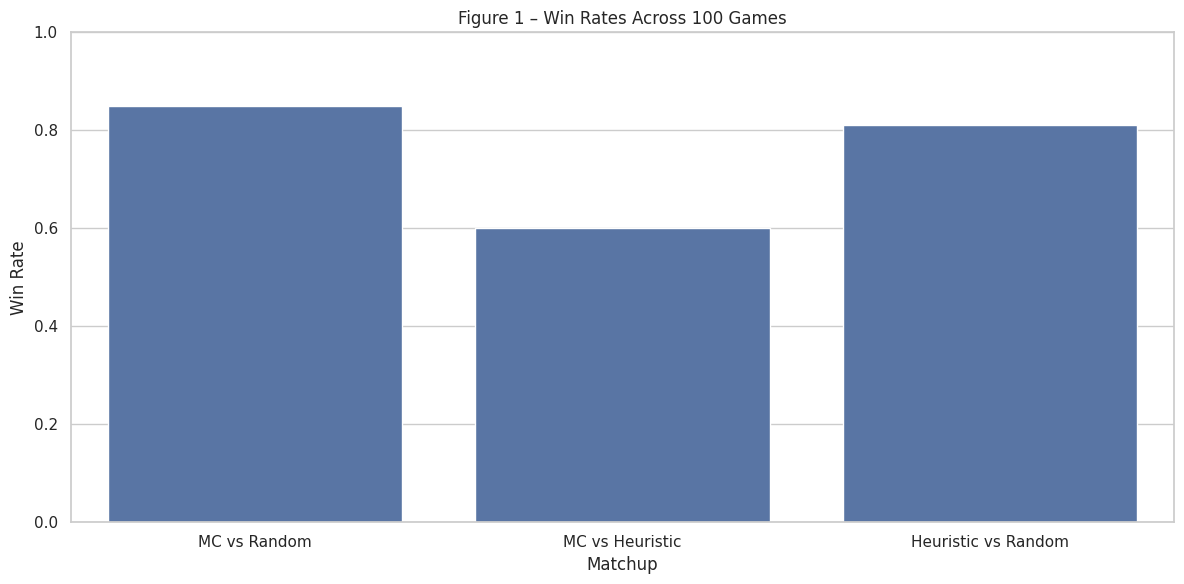


TABLE 2 – SCORE DIFFERENCE STATISTICS



,Matchup,Average Score Difference,Median Score Difference,Max Score Difference,Min Score Difference
0,MC vs Random,35.180,40.000,94.000,-56.000
1,MC vs Heuristic,6.220,8.000,78.000,-92.000
2,Heuristic vs Random,30.600,33.000,102.000,-74.000


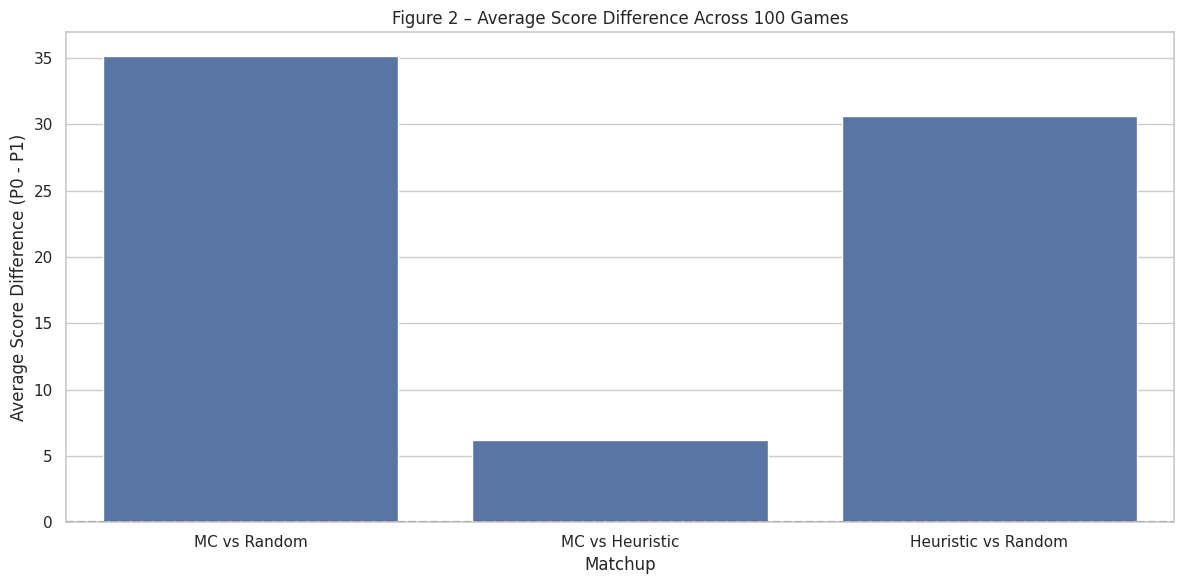


TABLE 3 – ROBUSTNESS STATISTICS



,Matchup,Standard Deviation,Variance
0,MC vs Random,35.167,1236.728
1,MC vs Heuristic,35.681,1273.112
2,Heuristic vs Random,37.009,1369.640


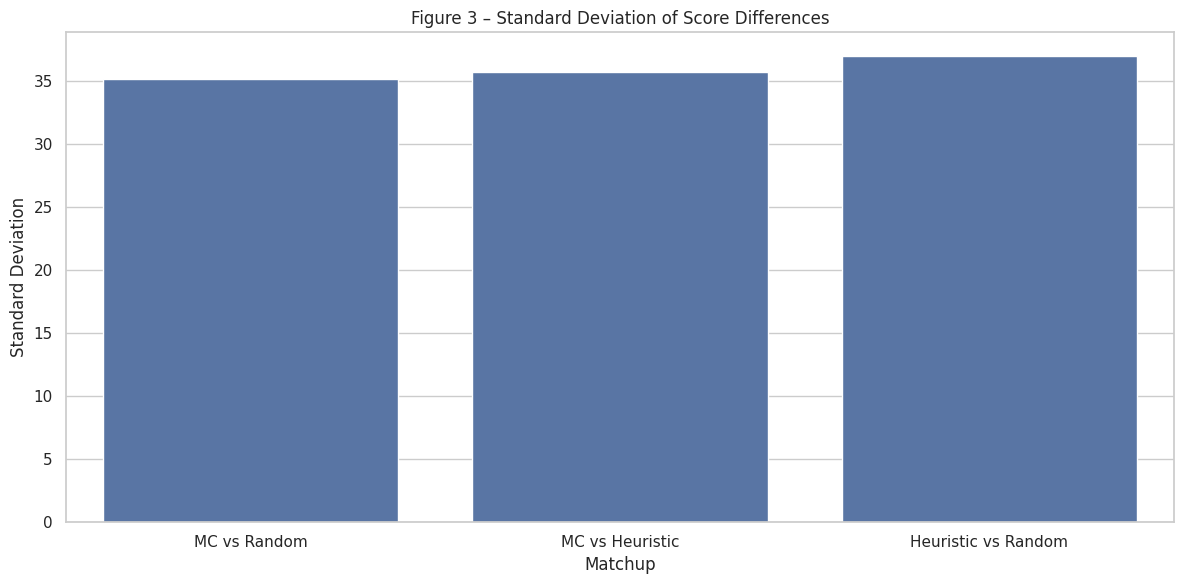


TABLE 4 – DISTRIBUTION ANALYSIS



,Matchup,Mean,Median,Standard Deviation
0,MC vs Random,35.180,40.000,35.167
1,MC vs Heuristic,6.220,8.000,35.681
2,Heuristic vs Random,30.600,33.000,37.009


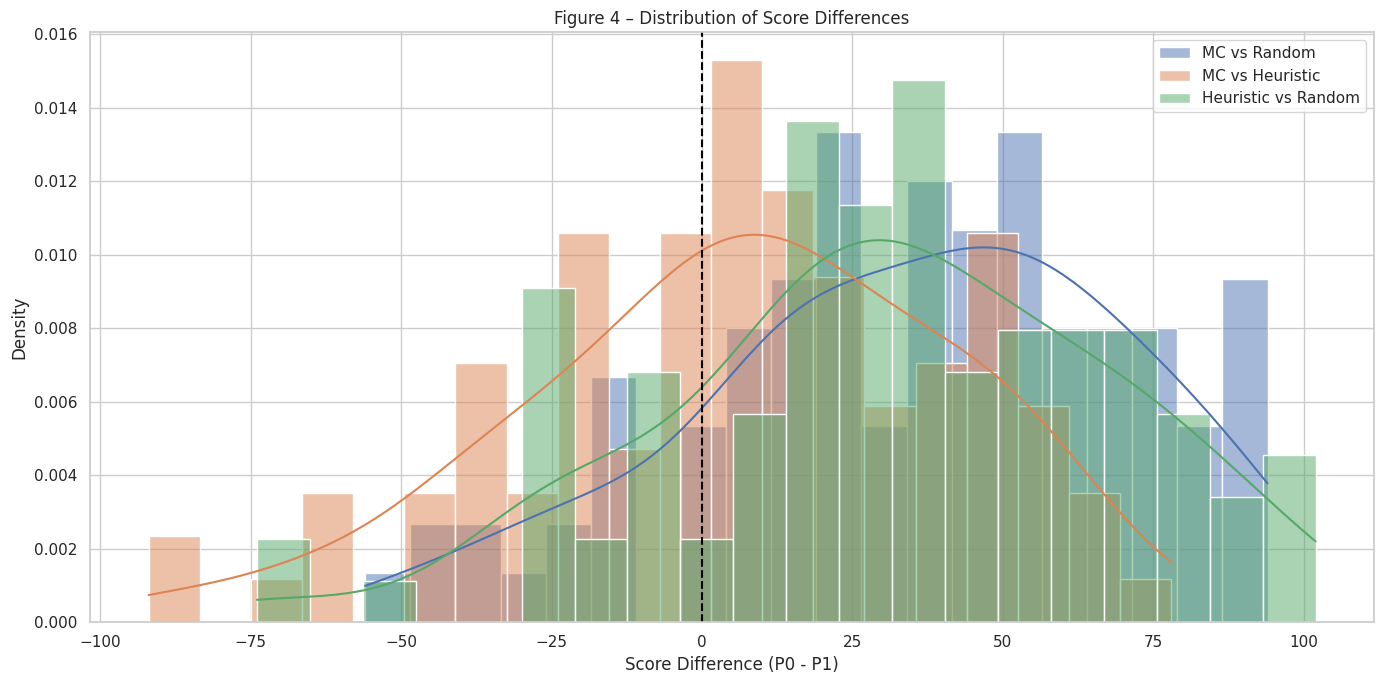


TABLE 5 – STABILITY / QUARTILE ANALYSIS



,Matchup,Q1,Median,Q3
0,MC vs Random,12.000,40.000,60.500
1,MC vs Heuristic,-16.500,8.000,30.500
2,Heuristic vs Random,10.000,33.000,58.500


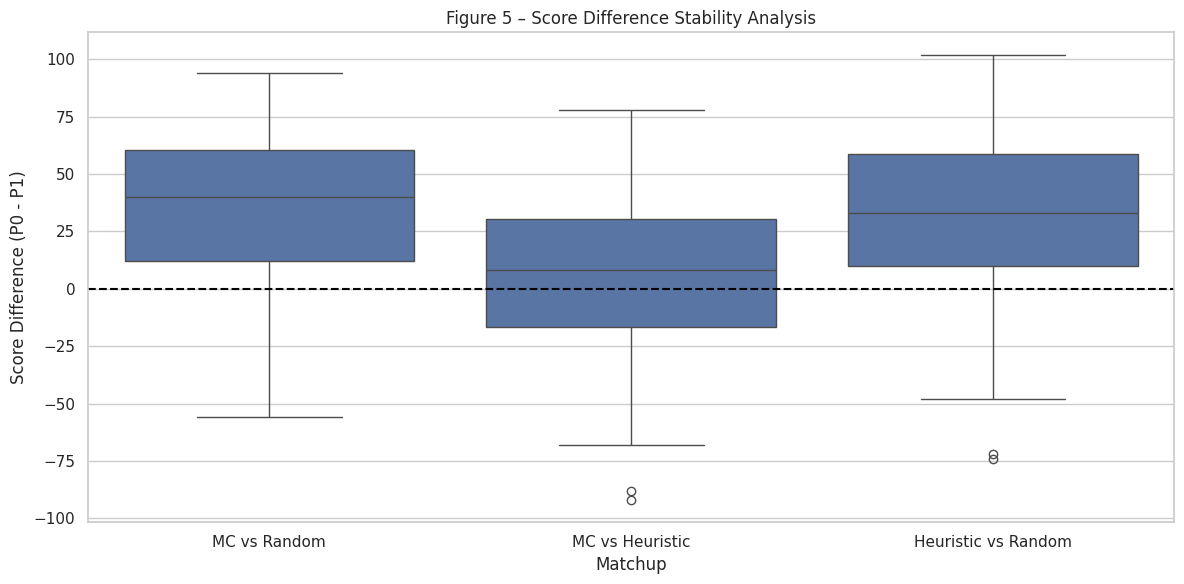

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from IPython.display import display

sns.set(style="whitegrid")


def plot_agent_comparison(
    results_mc_vs_random,
    results_mc_vs_heuristic,
    results_heuristic_vs_random,
    num_games
):

    # =========================================================
    # TABLE + GRAPH 1 : WIN RATES
    # =========================================================

    win_rate_df = pd.DataFrame({
        'Matchup': [
            'MC vs Random',
            'MC vs Heuristic',
            'Heuristic vs Random'
        ],

        'P0 Win Rate': [
            results_mc_vs_random['player_0_win_rate'],
            results_mc_vs_heuristic['player_0_win_rate'],
            results_heuristic_vs_random['player_0_win_rate']
        ],

        'P1 Win Rate': [
            results_mc_vs_random['player_1_win_rate'],
            results_mc_vs_heuristic['player_1_win_rate'],
            results_heuristic_vs_random['player_1_win_rate']
        ],

        'Tie Rate': [
            results_mc_vs_random['tie_rate'],
            results_mc_vs_heuristic['tie_rate'],
            results_heuristic_vs_random['tie_rate']
        ]
    })

    print("\nTABLE 1 – WIN RATE STATISTICS\n")

    display(
        win_rate_df.style.format({
            'P0 Win Rate': '{:.3f}',
            'P1 Win Rate': '{:.3f}',
            'Tie Rate': '{:.3f}'
        })
    )

    plt.figure(figsize=(12, 6))

    graph_win_df = pd.DataFrame({
        'Matchup': [
            'MC vs Random',
            'MC vs Heuristic',
            'Heuristic vs Random'
        ],

        'Win Rate': [
            results_mc_vs_random['player_0_win_rate'],
            results_mc_vs_heuristic['player_0_win_rate'],
            results_heuristic_vs_random['player_0_win_rate']
        ]
    })

    sns.barplot(
        x='Matchup',
        y='Win Rate',
        data=graph_win_df
    )

    plt.ylim(0, 1)

    plt.title(f'Figure 1 – Win Rates Across {num_games} Games')
    plt.ylabel('Win Rate')
    plt.xlabel('Matchup')

    plt.tight_layout()
    plt.show()

    # =========================================================
    # TABLE + GRAPH 2 : SCORE DIFFERENCES
    # =========================================================

    score_diff_df = pd.DataFrame({
        'Matchup': [
            'MC vs Random',
            'MC vs Heuristic',
            'Heuristic vs Random'
        ],

        'Average Score Difference': [
            results_mc_vs_random['average_score_difference_P0_minus_P1'],
            results_mc_vs_heuristic['average_score_difference_P0_minus_P1'],
            results_heuristic_vs_random['average_score_difference_P0_minus_P1']
        ],

        'Median Score Difference': [
            results_mc_vs_random['median_score_difference_P0_minus_P1'],
            results_mc_vs_heuristic['median_score_difference_P0_minus_P1'],
            results_heuristic_vs_random['median_score_difference_P0_minus_P1']
        ],

        'Max Score Difference': [
            results_mc_vs_random['max_score_difference_P0_minus_P1'],
            results_mc_vs_heuristic['max_score_difference_P0_minus_P1'],
            results_heuristic_vs_random['max_score_difference_P0_minus_P1']
        ],

        'Min Score Difference': [
            results_mc_vs_random['min_score_difference_P0_minus_P1'],
            results_mc_vs_heuristic['min_score_difference_P0_minus_P1'],
            results_heuristic_vs_random['min_score_difference_P0_minus_P1']
        ]
    })

    print("\nTABLE 2 – SCORE DIFFERENCE STATISTICS\n")

    display(
        score_diff_df.style.format({
            'Average Score Difference': '{:.3f}',
            'Median Score Difference': '{:.3f}',
            'Max Score Difference': '{:.3f}',
            'Min Score Difference': '{:.3f}'
        })
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x='Matchup',
        y='Average Score Difference',
        data=score_diff_df
    )

    plt.axhline(0, color='black', linestyle='--')

    plt.title(f'Figure 2 – Average Score Difference Across {num_games} Games')
    plt.ylabel('Average Score Difference (P0 - P1)')
    plt.xlabel('Matchup')

    plt.tight_layout()
    plt.show()

    # =========================================================
    # TABLE + GRAPH 3 : ROBUSTNESS
    # =========================================================

    robustness_df = pd.DataFrame({
        'Matchup': [
            'MC vs Random',
            'MC vs Heuristic',
            'Heuristic vs Random'
        ],

        'Standard Deviation': [
            results_mc_vs_random['std_score_difference_P0_minus_P1'],
            results_mc_vs_heuristic['std_score_difference_P0_minus_P1'],
            results_heuristic_vs_random['std_score_difference_P0_minus_P1']
        ],

        'Variance': [
            results_mc_vs_random['variance_score_difference_P0_minus_P1'],
            results_mc_vs_heuristic['variance_score_difference_P0_minus_P1'],
            results_heuristic_vs_random['variance_score_difference_P0_minus_P1']
        ]
    })

    print("\nTABLE 3 – ROBUSTNESS STATISTICS\n")

    display(
        robustness_df.style.format({
            'Standard Deviation': '{:.3f}',
            'Variance': '{:.3f}'
        })
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x='Matchup',
        y='Standard Deviation',
        data=robustness_df
    )

    plt.title('Figure 3 – Standard Deviation of Score Differences')
    plt.ylabel('Standard Deviation')
    plt.xlabel('Matchup')

    plt.tight_layout()
    plt.show()

    # =========================================================
    # TABLE + GRAPH 4 : DISTRIBUTION ANALYSIS
    # =========================================================

    distribution_df = pd.DataFrame({
        'Matchup': [
            'MC vs Random',
            'MC vs Heuristic',
            'Heuristic vs Random'
        ],

        'Mean': [
            np.mean(results_mc_vs_random['all_score_differences']),
            np.mean(results_mc_vs_heuristic['all_score_differences']),
            np.mean(results_heuristic_vs_random['all_score_differences'])
        ],

        'Median': [
            np.median(results_mc_vs_random['all_score_differences']),
            np.median(results_mc_vs_heuristic['all_score_differences']),
            np.median(results_heuristic_vs_random['all_score_differences'])
        ],

        'Standard Deviation': [
            np.std(results_mc_vs_random['all_score_differences']),
            np.std(results_mc_vs_heuristic['all_score_differences']),
            np.std(results_heuristic_vs_random['all_score_differences'])
        ]
    })

    print("\nTABLE 4 – DISTRIBUTION ANALYSIS\n")

    display(
        distribution_df.style.format({
            'Mean': '{:.3f}',
            'Median': '{:.3f}',
            'Standard Deviation': '{:.3f}'
        })
    )

    plt.figure(figsize=(14, 7))

    sns.histplot(
        results_mc_vs_random['all_score_differences'],
        label='MC vs Random',
        kde=True,
        bins=20,
        stat='density'
    )

    sns.histplot(
        results_mc_vs_heuristic['all_score_differences'],
        label='MC vs Heuristic',
        kde=True,
        bins=20,
        stat='density'
    )

    sns.histplot(
        results_heuristic_vs_random['all_score_differences'],
        label='Heuristic vs Random',
        kde=True,
        bins=20,
        stat='density'
    )

    plt.axvline(0, color='black', linestyle='--')

    plt.title('Figure 4 – Distribution of Score Differences')
    plt.xlabel('Score Difference (P0 - P1)')
    plt.ylabel('Density')

    plt.legend()

    plt.tight_layout()
    plt.show()

    # =========================================================
    # TABLE + GRAPH 5 : STABILITY ANALYSIS
    # =========================================================

    stability_df = pd.DataFrame({
        'Matchup': [
            'MC vs Random',
            'MC vs Heuristic',
            'Heuristic vs Random'
        ],

        'Q1': [
            np.percentile(results_mc_vs_random['all_score_differences'], 25),
            np.percentile(results_mc_vs_heuristic['all_score_differences'], 25),
            np.percentile(results_heuristic_vs_random['all_score_differences'], 25)
        ],

        'Median': [
            np.percentile(results_mc_vs_random['all_score_differences'], 50),
            np.percentile(results_mc_vs_heuristic['all_score_differences'], 50),
            np.percentile(results_heuristic_vs_random['all_score_differences'], 50)
        ],

        'Q3': [
            np.percentile(results_mc_vs_random['all_score_differences'], 75),
            np.percentile(results_mc_vs_heuristic['all_score_differences'], 75),
            np.percentile(results_heuristic_vs_random['all_score_differences'], 75)
        ]
    })

    print("\nTABLE 5 – STABILITY / QUARTILE ANALYSIS\n")

    display(
        stability_df.style.format({
            'Q1': '{:.3f}',
            'Median': '{:.3f}',
            'Q3': '{:.3f}'
        })
    )

    boxplot_df = pd.DataFrame({
        'Score Difference': (
            results_mc_vs_random['all_score_differences']
            + results_mc_vs_heuristic['all_score_differences']
            + results_heuristic_vs_random['all_score_differences']
        ),

        'Matchup': (
            ['MC vs Random'] * len(results_mc_vs_random['all_score_differences'])
            + ['MC vs Heuristic'] * len(results_mc_vs_heuristic['all_score_differences'])
            + ['Heuristic vs Random'] * len(results_heuristic_vs_random['all_score_differences'])
        )
    })

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        x='Matchup',
        y='Score Difference',
        data=boxplot_df
    )

    plt.axhline(0, color='black', linestyle='--')

    plt.title('Figure 5 – Score Difference Stability Analysis')
    plt.ylabel('Score Difference (P0 - P1)')
    plt.xlabel('Matchup')

    plt.tight_layout()
    plt.show()


# =========================================================
# RUN VISUALIZATION
# =========================================================

plot_agent_comparison(
    mc_vs_random_results,
    mc_vs_heuristic_results,
    heuristic_vs_random_results,
    num_games
)

# Human vs AI (Optional)

Lets you play against the AI from the terminal/notebook. By default, you are Player 0. Use human_player=1 to play second.

Note: When tricks resolve to 0 points won, it might not be logged and the next round starts inmediately.

In [37]:
def format_card(card):
    return f"{card.rank} of {card.suit}"

def human_agent(game, state):
    legal_cards = game.actions(state)

    print("\nYour hand:")
    for i, card in enumerate(legal_cards):
        print(f"{i}: {format_card(card)}")

    while True:
        choice = input("Choose a card number to play: ")

        try:
            choice = int(choice)
            if 0 <= choice < len(legal_cards):
                return legal_cards[choice]
            else:
                print("Invalid number. Pick one from the list.")
        except ValueError:
            print("Please enter a number.")

def play_human_vs_ai(ai_agent=monte_carlo_agent_hidden_info, human_player=0):
    game = BriscasGame()
    state = game.initial

    agents = {
        human_player: human_agent,
        1 - human_player: ai_agent
    }

    print("--- Briscas: Human vs AI ---")
    print(f"You are Player {human_player}")
    print(f"Trump card: {format_card(state.trump_card)}")

    while not game.terminal_test(state):
        player = state.current_player

        print("\n--------------------")
        print(f"Scores: You = {state.scores[human_player]}, AI = {state.scores[1-human_player]}")
        print(f"Current player: {'You' if player == human_player else 'AI'}")

        if state.trick:
            print("Current trick:")
            for p, c in state.trick:
                label = "You" if p == human_player else "AI"
                print(f"{label}: {format_card(c)}")

        move = agents[player](game, state)

        if player == human_player:
            print(f"You played: {format_card(move)}")
        else:
            print(f"AI played: {format_card(move)}")

        old_scores = dict(state.scores)
        state = game.result(state, move)

        if len(state.trick) == 0 and state.scores != old_scores:
            if state.scores[human_player] > old_scores[human_player]:
                print("You won the trick!")
            else:
                print("AI won the trick!")

    print("\n--- Game Over ---")
    print(f"Final score: You = {state.scores[human_player]}, AI = {state.scores[1-human_player]}")

    if state.scores[human_player] > state.scores[1-human_player]:
        print("You win!")
    elif state.scores[human_player] < state.scores[1-human_player]:
        print("AI wins!")
    else:
        print("Tie game!")

Run the following code cell to start the game against the AI agent.

In [ ]:
play_human_vs_ai()

# Report: Adversarial AI in Games - Monte Carlo Simulation for Briscas

## Abstract

This paper presents the implementation and evaluation of an adversarial artificial intelligence agent for the card game Briscas using Monte Carlo simulation techniques. Briscas is a partially observable trick-taking card game involving hidden information, probabilistic reasoning, and adversarial decision-making. These characteristics make the game an appropriate candidate for simulation-based AI methods.

Three agents were developed and evaluated throughout this project: a Random agent, a Heuristic agent, and a Monte Carlo-based agent. The objective of the experiments was to determine whether Monte Carlo simulation could outperform simpler decision-making strategies while maintaining robustness across multiple games.

The agents were evaluated using automated large-scale gameplay experiments. Performance metrics included win rate, score difference, variance, quartile analysis, and score distribution analysis. Experimental results demonstrated that the Monte Carlo agent consistently outperformed the Random agent and achieved stronger overall performance than the Heuristic agent. The results also showed that Briscas contains significant variance due to hidden information and stochastic gameplay.

The findings of this work demonstrate that Monte Carlo simulation provides an effective framework for adversarial reasoning in partially observable card games.

---

# I. Introduction

Artificial intelligence in games has historically served as an important research area for decision-making systems, adversarial search, and probabilistic reasoning. Traditional game-playing AI techniques such as minimax search perform effectively in fully observable deterministic games like chess. However, partially observable games introduce hidden information and uncertainty, significantly increasing the complexity of strategic reasoning.

Briscas is a trick-taking card game in which players must make decisions with incomplete knowledge of the game state. Since players do not know the exact cards held by their opponents, the game naturally introduces uncertainty into the decision-making process. As a result, deterministic search methods become less effective, and probabilistic approaches become more appropriate.

Monte Carlo simulation is a commonly used technique for handling uncertainty in adversarial domains [1]. Rather than attempting to compute exact optimal play, Monte Carlo methods estimate the value of actions by repeatedly simulating possible future game states. According to Browne et al. [2], Monte Carlo-based methods are particularly effective in games with large search spaces and incomplete information.

The purpose of this project was to design, implement, and experimentally evaluate a Monte Carlo-based adversarial AI agent for Briscas. In addition to developing the agent itself, the project focused heavily on statistical evaluation, robustness analysis, and comparative experimentation.

Three agents were implemented and compared:

1. Random Agent
2. Heuristic Agent
3. Monte Carlo Agent

The evaluation was performed using automated large-scale gameplay experiments involving a hundred games per match up.

---

# II. Background

## A. Adversarial Search

Adversarial search refers to decision-making methods in environments where multiple agents compete with conflicting objectives [3]. In classical adversarial search problems, agents attempt to maximize their own utility while minimizing the utility of their opponents.

Many adversarial search algorithms assume complete observability of the environment. Minimax search, for example, assumes that all players have access to the full game state [3]. However, card games such as Briscas violate this assumption because players cannot directly observe opponent hands.

## B. Monte Carlo Simulation

Monte Carlo simulation is a probabilistic search method that evaluates decisions through repeated random sampling [4]. Instead of attempting exhaustive deterministic search, Monte Carlo approaches estimate expected utility by simulating many future outcomes.

Monte Carlo methods have become widely used in modern game AI because they scale effectively in environments with:

* Large state spaces
* Uncertainty
* Hidden information
* Stochastic transitions

In this project, Monte Carlo simulation was used to estimate the expected value of legal actions in Briscas.

---

# III. Game Description

Briscas is a partially observable trick-taking card game in which players attempt to accumulate points through strategic card play. The game includes hidden information because players only observe:

* Their own hand
* Previously played cards
* The current trick
* The trump suit

The opponent's hand remains unknown throughout most of the game.

This creates several AI challenges:

1. Uncertainty regarding opponent actions.
2. Difficulty predicting future game states.
3. Inability to perform exact deterministic search.
4. Need for probabilistic reasoning.

Because of these characteristics, Briscas is well-suited for simulation-based adversarial AI approaches.

---

# IV. Methodology

## A. Agent Implementations

### 1) Random Agent

The Random agent served as the baseline system for evaluation. This agent selects a legal move uniformly at random and performs no strategic reasoning.

The purpose of the Random agent was to establish a minimum performance baseline against which stronger agents could be compared.

### 2) Heuristic Agent

The Heuristic agent used manually designed rules intended to approximate reasonable gameplay behavior. The heuristics prioritized actions such as preserving high-value cards, strategically using trump cards, and maximizing expected point gains.

Unlike the Random agent, the Heuristic agent incorporated domain-specific knowledge of Briscas. However, it did not explicitly simulate future game states.

### 3) Monte Carlo Agent

The Monte Carlo agent evaluated actions by repeatedly simulating possible future game trajectories. For each legal move available to the agent:

1. The move was applied to the current state.
2. Multiple random game continuations were simulated.
3. Final score outcomes were recorded.
4. The average reward of the move was estimated.
5. The move with the highest estimated reward was selected.

The implementation used 50 simulations per move during experimentation.

Monte Carlo simulation was selected because it naturally handles uncertainty and hidden information [2]. Rather than attempting to predict a single deterministic future, the algorithm estimates expected performance across many possible futures.

## B. Libraries and Tools

The implementation was developed using Python and Jupyter Notebook.

Several libraries were used throughout the project:

* NumPy for statistical analysis and numerical computation.
* Pandas for organizing experimental data.
* Matplotlib for graph generation.
* Seaborn for statistical visualizations.

These libraries were selected because they provide reliable tools for scientific experimentation and data analysis.

---

# V. Experimental Setup

The evaluation focused on measuring the effectiveness and robustness of the implemented agents.

Three primary matchups were tested:

1. Monte Carlo vs Random
2. Monte Carlo vs Heuristic
3. Heuristic vs Random

Each matchup was executed over a large number of games to reduce the impact of randomness and improve statistical reliability.

The experiments collected the following metrics:

* Win rate
* Tie rate
* Average score difference
* Median score difference
* Standard deviation
* Variance
* Quartile analysis
* Score distributions

According to Russell and Norvig [3], adversarial AI systems should be evaluated through repeated experimentation rather than isolated gameplay examples. Consequently, the project emphasized large-scale automated testing rather than anecdotal demonstrations.

---

# VI. Results

## A. Win Rate Analysis

The first experiment evaluated overall win rates across all agent matchups.

The Monte Carlo agent achieved an 85.0% win rate against the Random agent, while the Random agent achieved only a 15.0% win rate. No games in this matchup ended in ties.

Against the Heuristic agent, the Monte Carlo agent achieved a 60.0% win rate compared to the Heuristic agent's 38.0% win rate. The remaining 2.0% of games ended in ties.

The Heuristic agent also demonstrated substantial improvement over purely random play, achieving an 81.0% win rate against the Random agent.

These results were compiled into Table I.

<br>

<div align="center">

| Matchup             | P0 Win Rate | P1 Win Rate | Tie Rate |
| ------------------- | ----------: | ----------: | -------: |
| MC vs Random        |       0.850 |       0.150 |    0.000 |
| MC vs Heuristic     |       0.600 |       0.380 |    0.020 |
| Heuristic vs Random |       0.810 |       0.190 |    0.000 |

**Table 1: Win Rate Statistics**

</div>

<br>




Figure 1 visualizes the win rate comparison between the evaluated agents.

<br>

<div align="center">

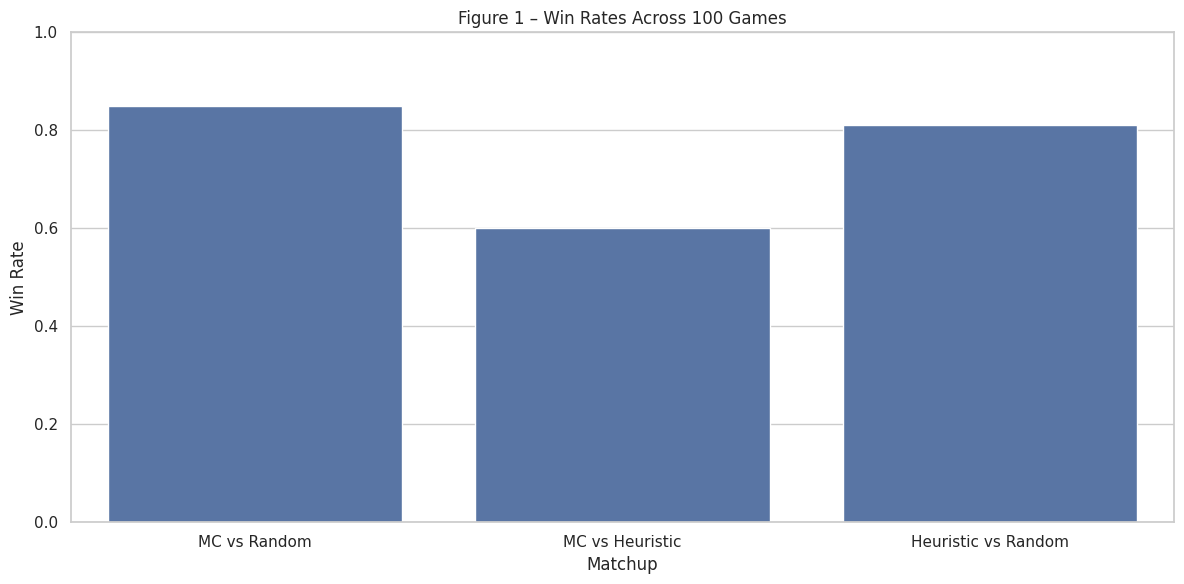

**Figure 1: Win Rate Comparison Across Agent Matchups**

</div>

<br>

The results indicate a clear hierarchy of performance:

Monte Carlo > Heuristic > Random.

This ordering strongly suggests that simulation-based reasoning provides a measurable advantage in Briscas. At the same time, the relatively competitive results between the Monte Carlo and Heuristic agents indicate that handcrafted strategic rules remain effective in many situations.

Importantly, the Monte Carlo agent did not achieve unrealistic dominance against the Heuristic agent. The relatively close matchup suggests that the game maintains meaningful strategic uncertainty and that the evaluation results are credible.

---

## B. Score Difference Analysis

While win rate measures overall success frequency, score difference analysis provides additional insight into the magnitude of victories.

The Monte Carlo agent achieved an average score difference of +35.18 against the Random agent, with a median score difference of +40.0. This indicates not only consistent victories, but also substantial dominance in terms of point accumulation.

Against the Heuristic agent, the Monte Carlo agent achieved a smaller but still positive average score difference of +6.22. The median score difference of +8.0 further suggests that the matchup was significantly more balanced.

The Heuristic agent achieved an average score difference of +30.60 against the Random agent, demonstrating that even a relatively simple heuristic strategy substantially outperformed purely random gameplay.

These results were compiled into Table II.

<br>

<div align="center">

| Matchup             | Average Score Difference | Median Score Difference | Max Score Difference | Min Score Difference |
| ------------------- | -----------------------: | ----------------------: | -------------------: | -------------------: |
| MC vs Random        |                   35.180 |                  40.000 |               94.000 |              -56.000 |
| MC vs Heuristic     |                    6.220 |                   8.000 |               78.000 |              -92.000 |
| Heuristic vs Random |                   30.600 |                  33.000 |              102.000 |              -74.000 |

**Table 2: Score Difference Statistics**

</div>

<br>

Figure 2 visualizes the average score differences across all evaluated matchups.

<br>

<div align="center">

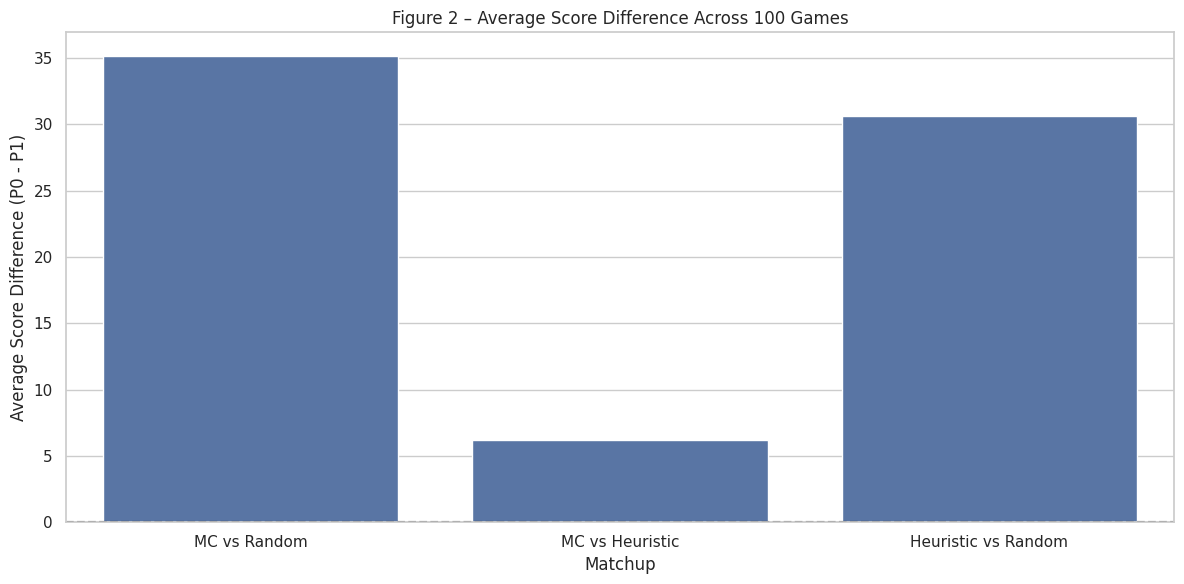

**Figure 2: Average Score Difference Across Agent Matchups**

</div>

<br>

The score difference analysis reinforces the conclusions obtained from the win rate experiments. The Monte Carlo agent consistently outperformed the Random agent and maintained a positive strategic advantage against the Heuristic agent.

However, the relatively small average advantage against the Heuristic agent demonstrates that handcrafted strategic reasoning remains competitive. This result is particularly important because it indicates that the benchmark opponent was meaningful rather than trivially weak.

---

## C. Robustness Analysis

The assignment emphasized robustness evaluation across multiple game conditions. Consequently, standard deviation and variance analysis were used to measure consistency across repeated simulations.

The Monte Carlo versus Random matchup produced a standard deviation of approximately 35.17 with a variance of 1236.73. Similarly, the Monte Carlo versus Heuristic matchup produced a standard deviation of approximately 35.68 with a variance of 1273.11.

The Heuristic versus Random matchup produced the largest standard deviation, approximately 37.01, with a variance of 1369.64. This suggests that although heuristic play substantially outperformed random play on average, the outcomes remained highly variable due to the stochastic and partially observable nature of Briscas.

These results were compiled into Table III.

<br>

<div align="center">

| Matchup             | Standard Deviation | Variance |
| ------------------- | -----------------: | -------: |
| MC vs Random        |             35.167 | 1236.728 |
| MC vs Heuristic     |             35.681 | 1273.112 |
| Heuristic vs Random |             37.009 | 1369.640 |

**Table 3: Robustness Statistics**

</div>

<br>

Figure 3 visualizes the standard deviation values across all experiments.

<br>

<div align="center">

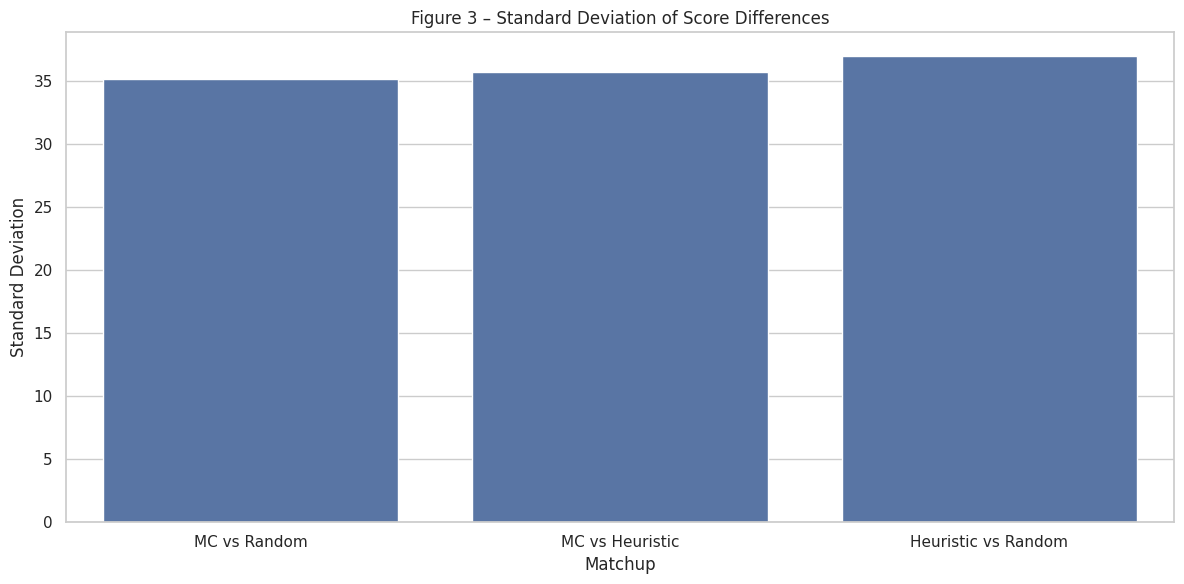

**Figure 3: Standard Deviation of Score Differences Across Experiments**

</div>

<br>

The results demonstrate that Briscas contains substantial variability due to hidden information and stochastic gameplay. Even strong agents occasionally experience unfavorable outcomes because card draws and hidden opponent actions introduce uncertainty.

Interestingly, the Monte Carlo agent exhibited slightly lower variability than the Heuristic agent when compared against the Random baseline. This suggests that Monte Carlo simulation may provide more stable strategic performance.

---

## D. Distribution Analysis

Distribution analysis was performed to better understand the overall spread of score differences across repeated simulations.

The Monte Carlo versus Random distribution exhibited a strong positive shift, indicating that the Monte Carlo agent achieved positive score differences consistently and substantially outperformed purely random gameplay.

In contrast, the Monte Carlo versus Heuristic distribution was centered much closer to zero, reflecting the significantly more competitive nature of the matchup. Although the Monte Carlo agent maintained a positive average score difference, the relatively high standard deviation suggests that outcomes remained highly variable due to hidden information and stochastic game dynamics.

These distribution statistics were compiled into Table IV.

<br>

<div align="center">

| Matchup             |   Mean | Median | Standard Deviation |
| ------------------- | -----: | -----: | -----------------: |
| MC vs Random        | 35.180 | 40.000 |             35.167 |
| MC vs Heuristic     |  6.220 |  8.000 |             35.681 |
| Heuristic vs Random | 30.600 | 33.000 |             37.009 |

**Table 4: Distribution Analysis**

</div>

<br>

Figure 4 visualizes the score difference distributions using histograms.


<br>

<div align="center">

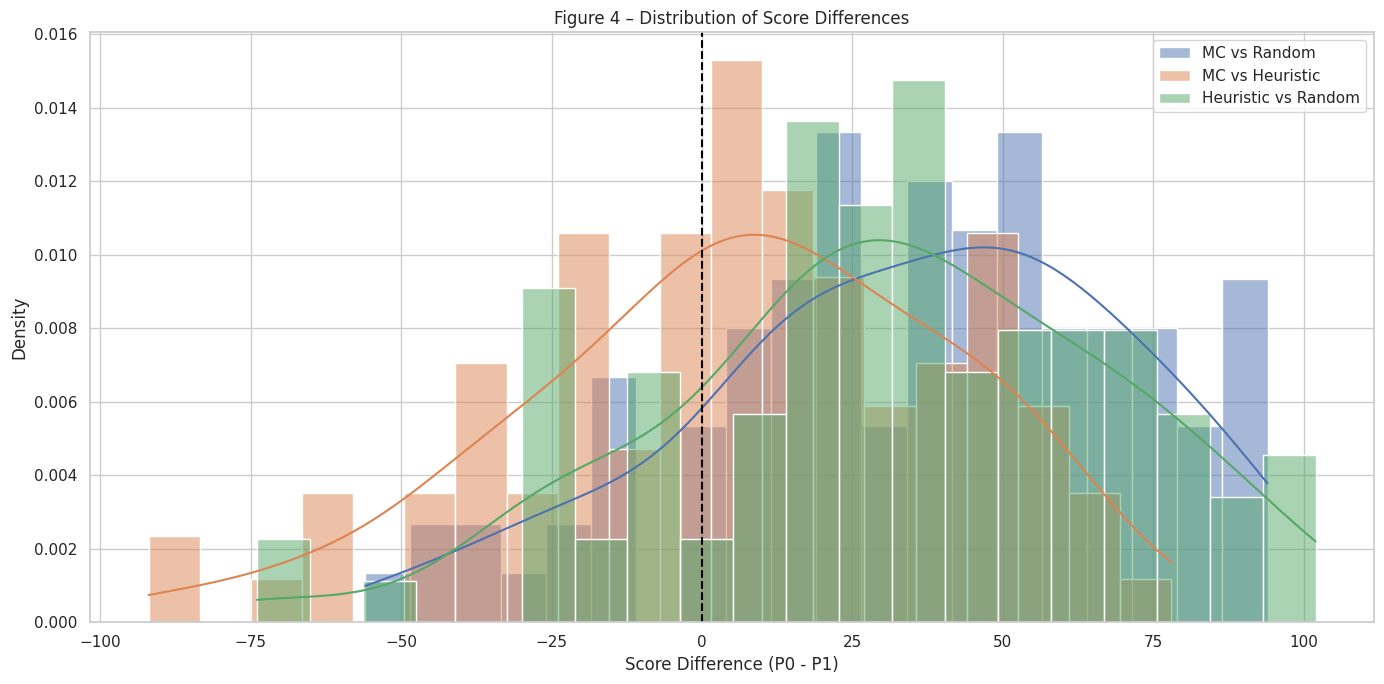

**Figure 4: Distribution of Score Differences Across Agent Matchups**

</div>

<br>

The distribution analysis provides additional evidence that the Monte Carlo agent consistently outperformed weaker opponents while remaining competitive against stronger heuristic strategies.

---

## E. Stability and Quartile Analysis

Quartile analysis was used to measure the stability and spread of score outcomes across repeated simulations.

For the Monte Carlo versus Random matchup:

* Q1 = 12.0
* Median = 40.0
* Q3 = 60.5

These values indicate that even lower-quartile outcomes were generally positive for the Monte Carlo agent, demonstrating strong and consistent performance against purely random gameplay.

For the Monte Carlo versus Heuristic matchup:

* Q1 = -16.5
* Median = 8.0
* Q3 = 30.5

These results indicate that the Heuristic agent occasionally achieved strong victories, particularly in lower-quartile outcomes. However, the Monte Carlo agent maintained a positive overall median advantage and stronger upper-quartile performance.

These quartile statistics were compiled into Table V.

<br>

<div align="center">

| Matchup             |      Q1 | Median |     Q3 |
| ------------------- | ------: | -----: | -----: |
| MC vs Random        |  12.000 | 40.000 | 60.500 |
| MC vs Heuristic     | -16.500 |  8.000 | 30.500 |
| Heuristic vs Random |  10.000 | 33.000 | 58.500 |

**Table 5: Stability / Quartile Analysis**

</div>

<br>

Figure 5 visualizes score stability through boxplot analysis.

<br>

<div align="center">

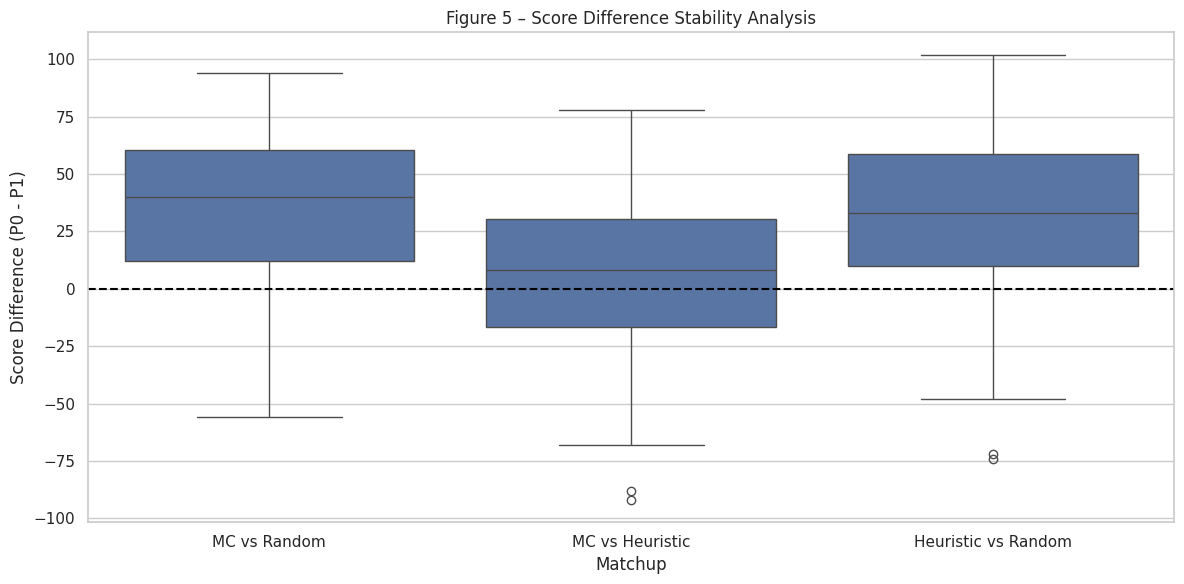

**Figure 5: Score Difference Stability and Quartile Analysis**

</div>

<br>


The quartile analysis demonstrates that the Monte Carlo agent achieved both stronger average performance and more consistent outcomes than the Random baseline. However, the relatively wide interquartile range observed against the Heuristic agent confirms that Briscas remains strategically competitive even when stronger AI methods are used.

---

# VII. Discussion

The experimental results demonstrate that Monte Carlo simulation provides a significant advantage in partially observable adversarial environments.

The Monte Carlo agent consistently achieved the strongest overall performance throughout the experiments. Against the Random agent, the Monte Carlo approach demonstrated overwhelming superiority in both win rate and score difference metrics.

Against the Heuristic agent, the Monte Carlo system maintained a smaller but still measurable advantage. This result is particularly important because it suggests that simulation-based reasoning improves decision quality beyond manually designed heuristics.

At the same time, the relatively high standard deviation values observed across experiments demonstrate that Briscas remains a highly stochastic environment. Hidden information and uncertain future draws introduce unavoidable variability into gameplay outcomes.

Consequently, even strong AI systems cannot guarantee deterministic performance in every game.

The experiments also illustrate the importance of large-scale evaluation. Single games would not have been sufficient to reliably evaluate agent strength because variance in individual outcomes is relatively high.

---

# VIII. Limitations

Several limitations were identified throughout the project.

First, the Monte Carlo agent relied on random rollouts rather than more sophisticated rollout policies. More advanced simulation strategies could potentially improve decision quality.

Second, the experiments used a fixed simulation count of 50 simulations per move. Higher simulation counts may improve accuracy at the cost of increased computational time.

Third, the project did not include opponent modeling or adaptive learning strategies. Future systems could attempt to infer opponent tendencies and dynamically adjust gameplay behavior.

Finally, human player evaluation was not extensively explored. Additional experiments involving human opponents could provide further insight into practical gameplay quality.

---

# IX. Conclusion

This paper presented the design and evaluation of a Monte Carlo-based adversarial AI agent for Briscas.

The project demonstrated that simulation-based reasoning significantly improves performance in partially observable card games. Experimental results showed that the Monte Carlo agent consistently outperformed Random agents and maintained a positive advantage against Heuristic agents.

The evaluation also highlighted the importance of robustness analysis and statistical experimentation when studying adversarial AI systems.

Overall, the project demonstrates that Monte Carlo simulation provides an effective framework for decision-making under uncertainty in adversarial game environments.

---

# References

[1] M. H. Kalos and P. A. Whitlock, Monte Carlo Methods. Wiley-VCH, 2008.

[2] C. B. Browne et al., “A Survey of Monte Carlo Tree Search Methods,” IEEE Transactions on Computational Intelligence and AI in Games, vol. 4, no. 1, pp. 1-43, 2012.

[3] S. Russell and P. Norvig, Artificial Intelligence: A Modern Approach, 4th ed. Pearson, 2020.

[4] R. S. Sutton and A. G. Barto, Reinforcement Learning: An Introduction, 2nd ed. MIT Press, 2018.

---

# Disclaimer of AI Tools

AI-based tools, including Large Language Models (LLMs), were used to assist with writing, formatting, and reviewing portions of this report. All content, was revised and checked by the authors.